# Time-domain heterodyning pipeline

Built incrementally. Each section adds one stage of the
`IMRPhenomXAS_NRTidalv3` -> heterodyne -> truncate -> downsample pipeline.

## Stage 1a - The prior space (two priors: broad + constrained)

Both priors are built and sampled **entirely through sage + gwconfig**
(`DistributionSampler`) — no hand-rolled samplers. 200k samples each, plotted
separately below.

| param | **broad** | **constrained** (realistic / EM-bright) |
|---|---|---|
| mass1, mass2 | U[0.75, 3.0] Msun | U[0.75, 2.1] Msun (upper ~ M_TOV) |
| spins | isotropic on sphere, \|chi\| <= 0.25 | isotropic on sphere, \|chi\| <= 0.05 |
| lambda1, lambda2 | U[0, 15000], lambda1 <= lambda2 | U[0, 5000], lambda1 <= lambda2 |
| distance | uniform in comoving volume, O3/O4 horizon | same |
| tc, inclination, sky, phases | gwconfig defaults | same |

Config files: `runs/bns/gwconfig_ewbroad.yaml`, `runs/bns/gwconfig_ewconstrained.yaml`.

**Constrained upper mass = 2.1 Msun ~ M_TOV** (maximum non-rotating NS mass).
Highest precisely measured NS: PSR J0740+6620 = 2.08 +/- 0.07 Msun (Fonseca et
al. 2021; Cromartie et al. 2020); GW170817 multimessenger limits give M_TOV
<~ 2.16-2.17 Msun (Margalit & Metzger 2017; Rezzolla, Most & Weih 2018). A
component above M_TOV is a black hole -> no tidal disruption, no ejecta; total
mass above the prompt-collapse threshold likewise suppresses the kilonova
(Bauswein et al. 2013).

sage additions these configs rely on:
- `uniform_comoving_volume` distance distribution (astropy Planck18)
- `lambda_order` constraint (heavier m1 -> smaller lambda1)
- isotropic spin via `spherical_to_cartesian` -> aligned `chi_z` (o3 convention)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml, torch

# Register a CPU / float64 sage config so DistributionSampler can be built.
from sage.core.base_classes import BaseConfig, BaseDataConfig
from sage.core.config import register_configs

class _Cfg:
    batch_size = 2; device = "cpu"; dtype = torch.float64
    autocast = False; class_balance = 0.5

class _DataCfg:
    sample_rate = 2048.0; signal_low_frequency_cutoff = 20.0
    noise_low_frequency_cutoff = 15.0
    sample_length_in_s = 287.0; padding_length_in_s = 4.0

register_configs(BaseConfig(_Cfg()), BaseDataConfig(_DataCfg()))

from sage.data.waveform.sampler import DistributionSampler
%matplotlib inline

In [2]:
# ----------------------------------------------------------------------
# Stage 1a: sample both priors via sage DistributionSampler + gwconfig.
# Comoving-volume distance, lambda_order, and isotropic spin are all
# provided by sage (no hand-rolled samplers).
# ----------------------------------------------------------------------
from pathlib import Path
import sage
REPO = Path(sage.__file__).resolve().parents[1]     # repo root, cwd-independent

CONFIGS = {
    'broad':       REPO / 'runs/bns/gwconfig_ewbroad.yaml',
    'constrained': REPO / 'runs/bns/gwconfig_ewconstrained.yaml',
}

# distance upper edge: O3 or O4 BNS horizon (uniform in comoving volume)
RUN = 'O4'                                     # 'O3' or 'O4'
HORIZON_MPC = {'O3': 290.0, 'O4': 450.0}[RUN]

N = 200_000

def sample_prior(path, seed):
    with open(path) as f:
        cfg = yaml.safe_load(f)
    cfg['priors']['distance']['max'] = HORIZON_MPC          # apply O3/O4 option
    gen = torch.Generator(device='cpu'); gen.manual_seed(seed)
    sampler = DistributionSampler(cfg, device='cpu', dtype=torch.float64, generator=gen)
    batch = sampler(N)                                      # (N, num_params) tensor
    return {k: batch[:, i].cpu().numpy() for k, i in sampler.param_index.items()}

priors = {
    'broad':       sample_prior(CONFIGS['broad'],       seed=20260623),
    'constrained': sample_prior(CONFIGS['constrained'], seed=20260624),
}

for tag, P in priors.items():
    print('%-12s Mc[%.3f,%.3f] med %.3f | m1[%.2f,%.2f] | |chi1z|<=%.3f | '
          'L1<=L2:%s | dL[%.0f,%.0f] Mpc'
          % (tag, P['mchirp'].min(), P['mchirp'].max(), np.median(P['mchirp']),
             P['mass1'].min(), P['mass1'].max(), np.abs(P['chi1z']).max(),
             bool((P['lambda1'] <= P['lambda2']).all()),
             P['distance'].min(), P['distance'].max()))
print('distance: uniform in comoving volume, %s horizon = %.0f Mpc' % (RUN, HORIZON_MPC))

broad        Mc[0.657,2.606] med 1.534 | m1[0.76,3.00] | |chi1z|<=0.249 | L1<=L2:True | dL[12,450] Mpc
constrained  Mc[0.654,1.824] med 1.194 | m1[0.75,2.10] | |chi1z|<=0.050 | L1<=L2:True | dL[11,450] Mpc
distance: uniform in comoving volume, O4 horizon = 450 Mpc


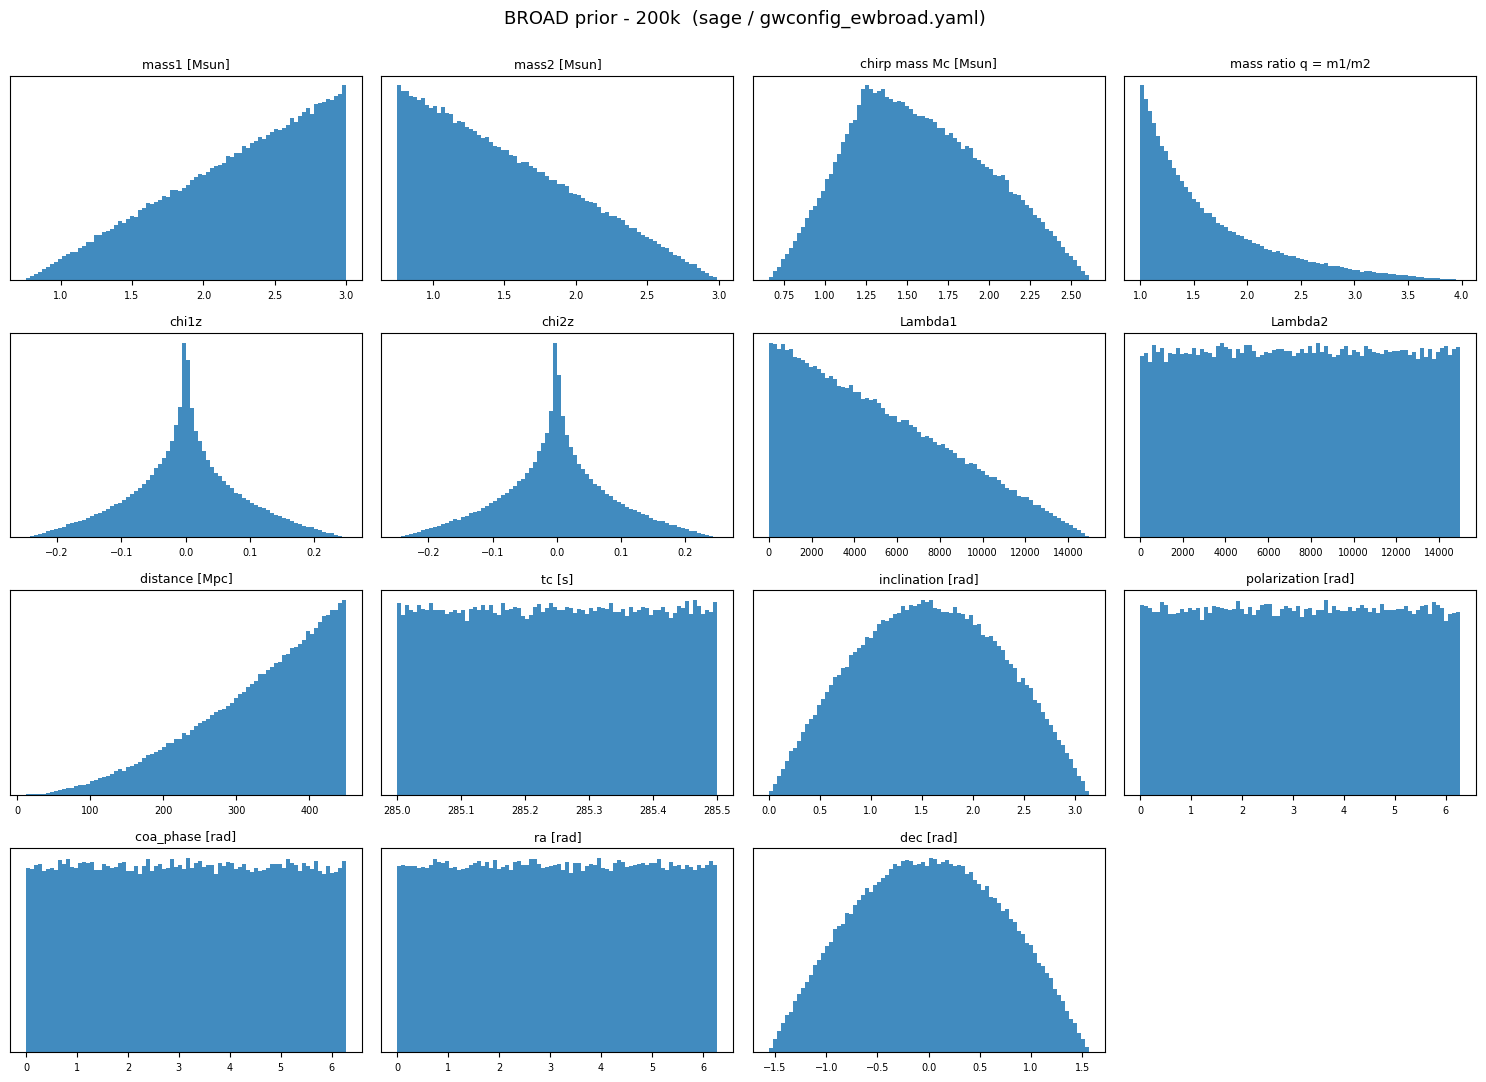

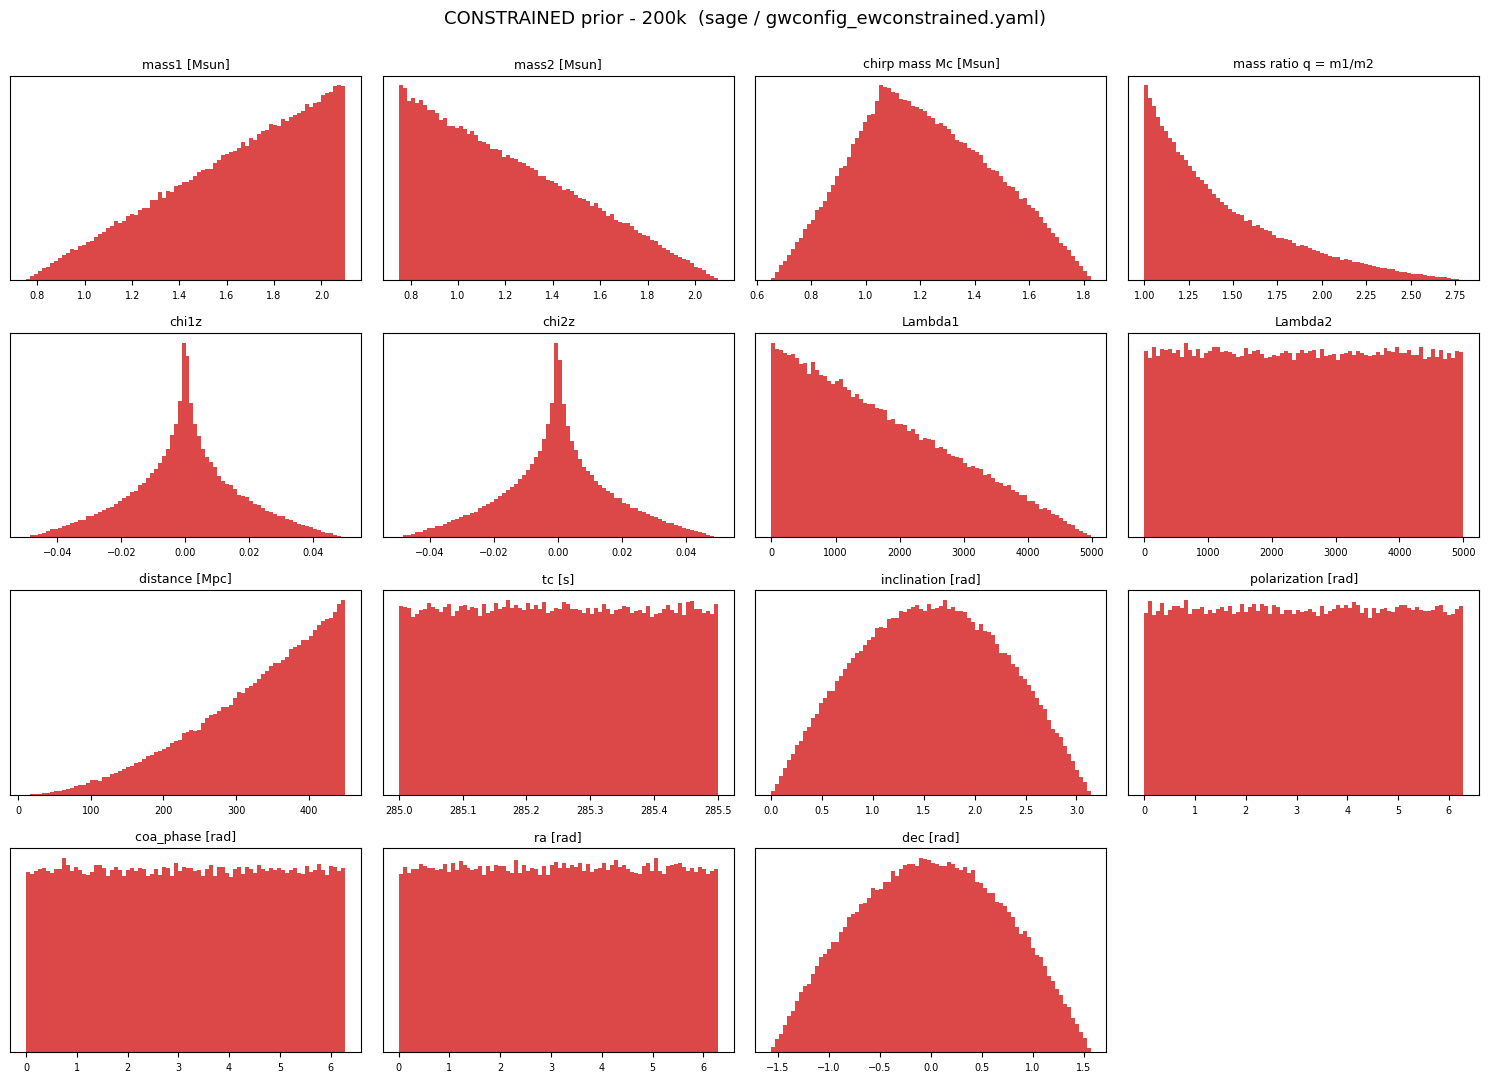

In [3]:
# ----------------------------------------------------------------------
# Distribution of every parameter -- one figure per prior (separate plots)
# ----------------------------------------------------------------------
labels = {
    'mass1':'mass1 [Msun]','mass2':'mass2 [Msun]','mchirp':'chirp mass Mc [Msun]',
    'q':'mass ratio q = m1/m2','chi1z':'chi1z','chi2z':'chi2z',
    'lambda1':'Lambda1','lambda2':'Lambda2','distance':'distance [Mpc]','tc':'tc [s]',
    'inclination':'inclination [rad]','polarization':'polarization [rad]',
    'coa_phase':'coa_phase [rad]','ra':'ra [rad]','dec':'dec [rad]',
}
order = ['mass1','mass2','mchirp','q','chi1z','chi2z','lambda1','lambda2',
         'distance','tc','inclination','polarization','coa_phase','ra','dec']

def plot_prior(P, title, color):
    fig, axes = plt.subplots(4, 4, figsize=(15, 11)); axes = axes.ravel()
    for ax, k in zip(axes, order):
        ax.hist(P[k], bins=80, color=color, alpha=0.85)
        ax.set_title(labels[k], fontsize=9); ax.tick_params(labelsize=7); ax.set_yticks([])
    for ax in axes[len(order):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()

plot_prior(priors['broad'],
           'BROAD prior - 200k  (sage / gwconfig_ewbroad.yaml)', 'C0')
plot_prior(priors['constrained'],
           'CONSTRAINED prior - 200k  (sage / gwconfig_ewconstrained.yaml)', 'C3')

### Requirements list (notes)

1. component masses - 0.75 to 3 Msun (uniform prior, double Gaussian 190425 paper)
2. EOS based search -
3. Lambda prior - U[0, 15000], U[0, 5000], astrophysically reasonable Lambda would mean Lambda1 < Lambda2. More massive, smaller Lambda.
4. Uniform in comoving volume. O3 or O4 sensitiviity for upper limit of distance
5. Spins - 0.05 mag for astrophysically interesting (restrict lambda to 5000), 0.25 for broad; uniform spin distributed on the sphere
6. 10 seconds before merger

## Stage 1b - Simple Heterodyning Transform

Minimal sanity check of `sage/dsp/heterodyne.heterodyne`: a pure real sine at
`f0 = 40 Hz`, demodulated by its **exact known phase** `Phi(t) = 2*pi*f0*t`.
Because the template phase matches the signal exactly, the heterodyned output
collapses to **DC (0 Hz)**. Shown before vs after in the time domain (TD),
frequency domain (FD), and time-frequency (TF, spectrogram).

`before` is the analytic signal of the sine (its real part *is* the sine);
`after = heterodyne(x, exp(i*Phi))` is the complex baseband result.

sine f0 = 40.0 Hz
after heterodyne:  |z| mean=1.0000 std=1.2e-14   inst.freq mean=5.48e-16 Hz  max|.|=6.57e-12 Hz


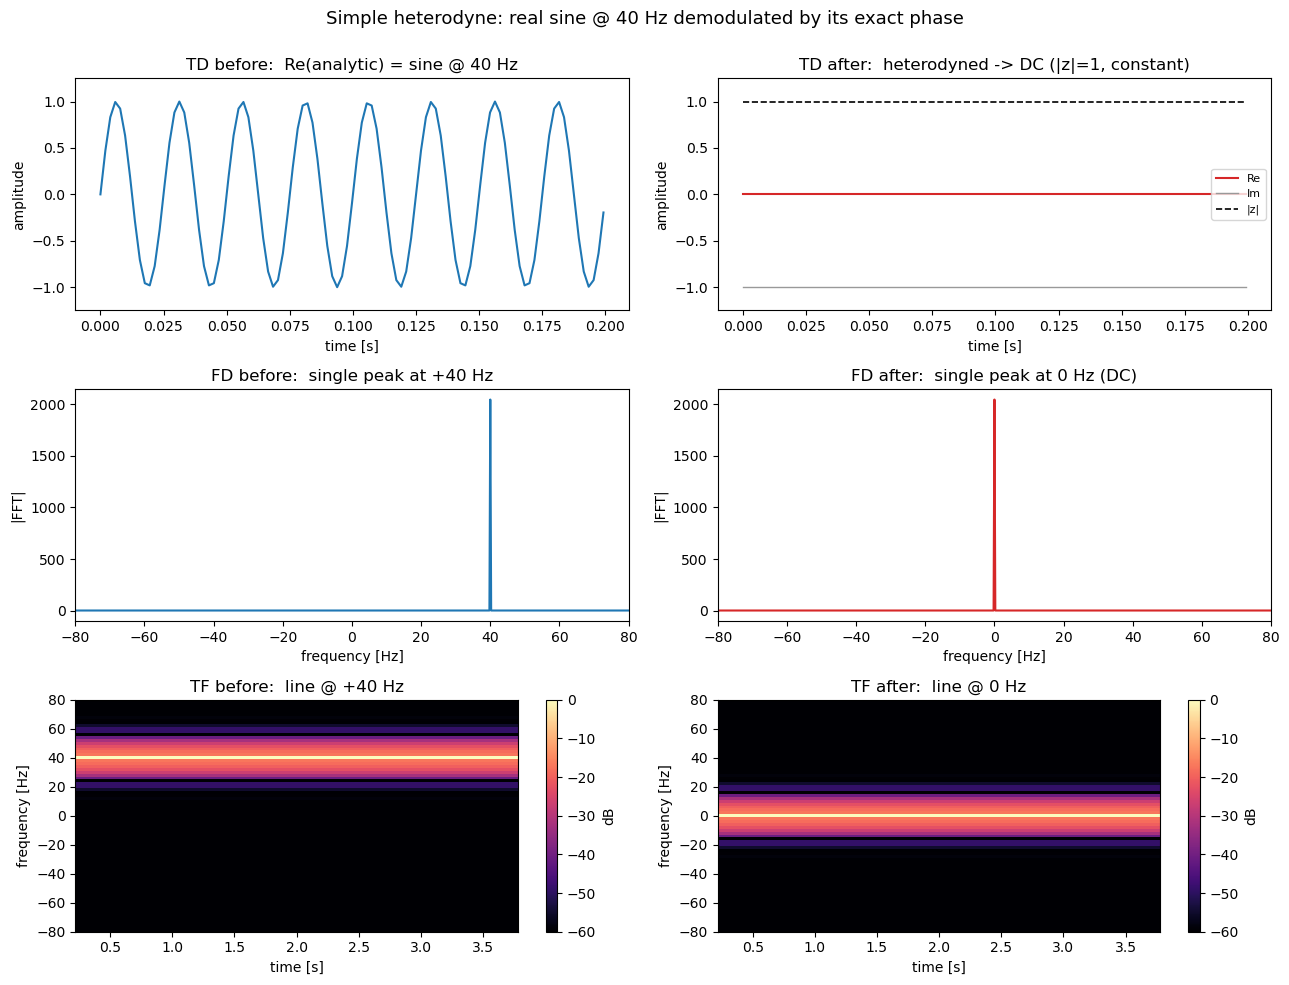

In [4]:
# ----------------------------------------------------------------------
# Simple heterodyne demo: real sine @ f0, demodulated by its EXACT phase
# ----------------------------------------------------------------------
from scipy.signal import spectrogram
from sage.dsp.heterodyne import heterodyne              # lean hot path: complex in, complex out
from sage.dsp.helpers import analytic_signal, instantaneous_frequency   # DSP helpers

fs = 512.0                     # sample rate [Hz]
T  = 4.0                       # duration [s]
n  = int(fs * T)
t  = np.arange(n) / fs
f0 = 40.0                      # sine frequency [Hz]

phi_exact = 2 * np.pi * f0 * t         # EXACT known phase of the sine
x = np.sin(phi_exact)                  # the simple real sine wave

template = np.exp(1j * phi_exact)      # exp(i * exact phase) = reference oscillation
before = analytic_signal(x)            # complex analytic signal (Re(before) == x)
after  = heterodyne(before, template)  # before * exp(-i*phi_exact)  ->  DC

f_after = instantaneous_frequency(after, dt=1 / fs)
print("sine f0 = %.1f Hz" % f0)
print("after heterodyne:  |z| mean=%.4f std=%.1e   inst.freq mean=%.2e Hz  max|.|=%.2e Hz"
      % (np.abs(after).mean(), np.abs(after).std(), f_after.mean(), np.abs(f_after).max()))
# note: since x = sin, analytic(x) = -i*exp(i*phi), so the DC constant is -i
#       (Re=0, Im=-1) -- an irrelevant global phase; what matters is |z|=1, IF=0.
# The FFT of `after` has exactly ONE nonzero bin (0 Hz); its width is the bin
# resolution df = 1/T = 0.25 Hz.

# ----------------------------------------------------------------------
# before vs after, in TD / FD / TF
# ----------------------------------------------------------------------
fig, ax = plt.subplots(3, 2, figsize=(13, 10))

# --- TD: real part over a short window ---
w = t < 0.2
ax[0, 0].plot(t[w], before.real[w], color='C0')
ax[0, 0].set_title('TD before:  Re(analytic) = sine @ %g Hz' % f0)
ax[0, 0].set_ylim(-1.25, 1.25)
ax[0, 1].plot(t[w], after.real[w], color='C3', label='Re')
ax[0, 1].plot(t[w], after.imag[w], color='0.6', lw=1, label='Im')
ax[0, 1].plot(t[w], np.abs(after[w]), color='k', lw=1.2, ls='--', label='|z|')
ax[0, 1].set_title('TD after:  heterodyned -> DC (|z|=1, constant)')
ax[0, 1].set_ylim(-1.25, 1.25); ax[0, 1].legend(fontsize=8, loc='center right')
for a in ax[0]:
    a.set_xlabel('time [s]'); a.set_ylabel('amplitude')

# --- FD: two-sided magnitude spectrum (single DC peak, width df = 1/T) ---
freqs = np.fft.fftshift(np.fft.fftfreq(n, d=1 / fs))
Xb = np.fft.fftshift(np.abs(np.fft.fft(before)))
Xa = np.fft.fftshift(np.abs(np.fft.fft(after)))
ax[1, 0].plot(freqs, Xb, color='C0'); ax[1, 0].set_title('FD before:  single peak at +%g Hz' % f0)
ax[1, 1].plot(freqs, Xa, color='C3'); ax[1, 1].set_title('FD after:  single peak at 0 Hz (DC)')
for a in ax[1]:
    a.set_xlim(-80, 80)
    a.set_xlabel('frequency [Hz]'); a.set_ylabel('|FFT|')

# --- TF: two-sided spectrogram (detrend=False so the DC line is kept) ---
def spec(z):
    fS, tS, S = spectrogram(z, fs=fs, nperseg=256, noverlap=224, detrend=False,
                            return_onesided=False, scaling='spectrum')
    fS = np.fft.fftshift(fS)
    S = np.fft.fftshift(S, axes=0)
    return fS, tS, 10 * np.log10(S + 1e-20)

for col, (z, ttl) in enumerate([(before, 'TF before:  line @ +%g Hz' % f0),
                                (after,  'TF after:  line @ 0 Hz')]):
    fS, tS, SdB = spec(z)
    pc = ax[2, col].pcolormesh(tS, fS, SdB, shading='auto', cmap='magma',
                               vmin=SdB.max() - 60, vmax=SdB.max())
    ax[2, col].set_ylim(-80, 80); ax[2, col].set_title(ttl)
    ax[2, col].set_xlabel('time [s]'); ax[2, col].set_ylabel('frequency [Hz]')
    fig.colorbar(pc, ax=ax[2, col], label='dB')

fig.suptitle('Simple heterodyne: real sine @ %g Hz demodulated by its exact phase' % f0,
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Wrong reference: too high vs too low

The same 40 Hz sine, heterodyned against a reference that is **matched**, **too
high**, and **too low**. The residual sits at `f0 - f_ref`, so:

- matched → **0 Hz** (DC),
- reference too high → **negative** residual,
- reference too low → **positive** residual.

This is the two-sided residual that off-median GW signals produce: a
faster-than-reference chirp lands on one side of DC, a slower one on the other.

matched              f_ref= 40.0 Hz  ->  residual IF =  +0.00 Hz  (expect +0)
reference too HIGH   f_ref= 50.0 Hz  ->  residual IF = -10.00 Hz  (expect -10)
reference too LOW    f_ref= 30.0 Hz  ->  residual IF = +10.00 Hz  (expect +10)


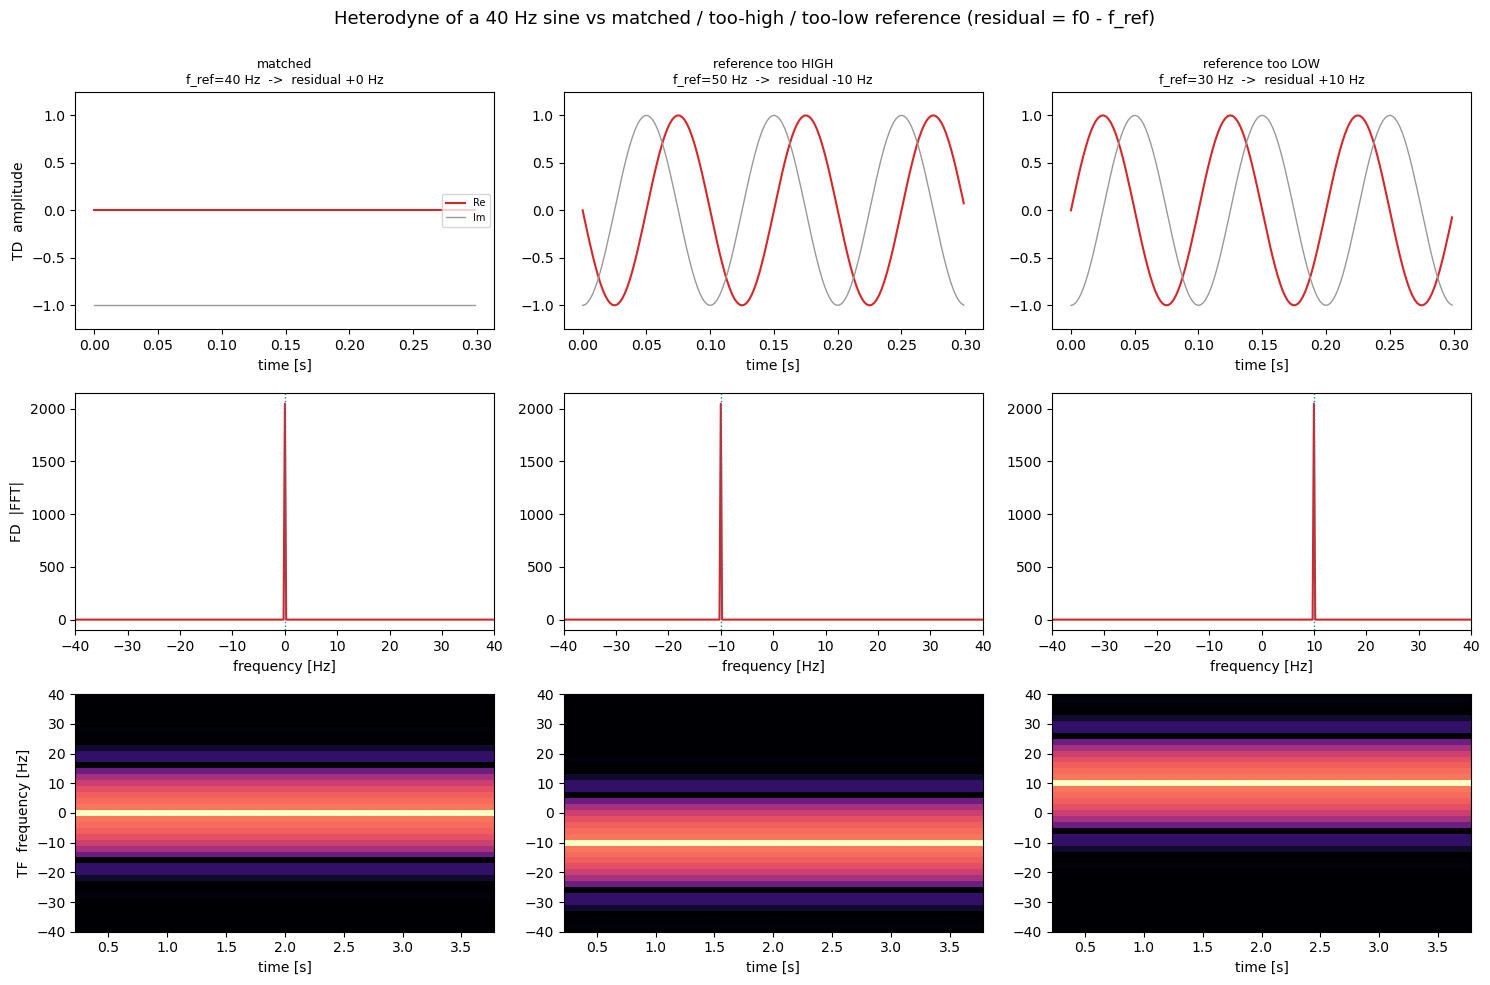

In [5]:
# ----------------------------------------------------------------------
# Wrong reference: same sine @ f0, heterodyned against a reference that is
# matched, too HIGH, and too LOW.  Residual sits at (f0 - f_ref):
#   matched  -> 0 Hz (DC)
#   too high -> NEGATIVE residual   (f0 - f_ref < 0)
#   too low  -> POSITIVE residual   (f0 - f_ref > 0)
# This is exactly the two-sided residual that off-median GW signals produce.
# ----------------------------------------------------------------------
from scipy.signal import spectrogram
from sage.dsp.heterodyne import heterodyne
from sage.dsp.helpers import analytic_signal, instantaneous_frequency

fs = 512.0; T = 4.0; n = int(fs * T); t = np.arange(n) / fs
f0 = 40.0            # signal frequency [Hz]
d_ref = 10.0         # how far the reference is off [Hz]

x = np.sin(2 * np.pi * f0 * t)
z = analytic_signal(x)                       # complex analytic signal of the sine

cases = [
    ('matched',           f0),
    ('reference too HIGH', f0 + d_ref),
    ('reference too LOW',  f0 - d_ref),
]

freqs = np.fft.fftshift(np.fft.fftfreq(n, d=1 / fs))

def spec(zz):
    fS, tS, S = spectrogram(zz, fs=fs, nperseg=256, noverlap=224, detrend=False,
                            return_onesided=False, scaling='spectrum')
    return np.fft.fftshift(fS), tS, 10 * np.log10(np.fft.fftshift(S, axes=0) + 1e-20)

# numeric confirmation
for name, f_ref in cases:
    a = heterodyne(z, np.exp(1j * 2 * np.pi * f_ref * t))
    fmeas = instantaneous_frequency(a, 1 / fs)[100:-100].mean()
    print("%-20s f_ref=%5.1f Hz  ->  residual IF = %+6.2f Hz  (expect %+g)"
          % (name, f_ref, fmeas, f0 - f_ref))

fig, ax = plt.subplots(3, 3, figsize=(15, 10))
w = t < 0.3
for col, (name, f_ref) in enumerate(cases):
    after = heterodyne(z, np.exp(1j * 2 * np.pi * f_ref * t))    # residual at f0 - f_ref
    res = f0 - f_ref
    # TD (Re / Im)
    ax[0, col].plot(t[w], after.real[w], color='C3', label='Re')
    ax[0, col].plot(t[w], after.imag[w], color='0.6', lw=1, label='Im')
    ax[0, col].set_ylim(-1.25, 1.25)
    ax[0, col].set_title('%s\nf_ref=%g Hz  ->  residual %+g Hz' % (name, f_ref, res), fontsize=9)
    ax[0, col].set_xlabel('time [s]')
    if col == 0:
        ax[0, col].set_ylabel('TD  amplitude'); ax[0, col].legend(fontsize=7, loc='center right')
    # FD (two-sided |FFT|)
    Xa = np.fft.fftshift(np.abs(np.fft.fft(after)))
    ax[1, col].plot(freqs, Xa, color='C3'); ax[1, col].set_xlim(-40, 40)
    ax[1, col].axvline(res, color='C0', ls=':', lw=1)
    ax[1, col].set_xlabel('frequency [Hz]')
    if col == 0:
        ax[1, col].set_ylabel('FD  |FFT|')
    # TF (spectrogram)
    fS, tS, SdB = spec(after)
    ax[2, col].pcolormesh(tS, fS, SdB, shading='auto', cmap='magma',
                          vmin=SdB.max() - 60, vmax=SdB.max())
    ax[2, col].set_ylim(-40, 40); ax[2, col].axhline(res, color='w', ls=':', lw=0.8)
    ax[2, col].set_xlabel('time [s]')
    if col == 0:
        ax[2, col].set_ylabel('TF  frequency [Hz]')

fig.suptitle('Heterodyne of a %g Hz sine vs matched / too-high / too-low reference '
             '(residual = f0 - f_ref)' % f0, fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Stage 1c - real BNS signal vs higher / lower chirp-mass reference

Same experiment as the sine, now with the actual `IMRPhenomXAS_NRTidalv3`
generator. A BNS signal is heterodyned against a reference of the **same**, a
**higher**, and a **lower** chirp mass (via uniform ±10 % mass scaling).

Unlike the constant-frequency sine, the chirp residual **sweeps**: it is ≈ 0
early (where the two chirps nearly coincide) and grows toward merger (where
their instantaneous frequencies diverge, as `f ∝ Mc^(-5/8)` at fixed
time-to-merger). The sign of the residual encodes the chirp-mass offset:

- **same Mc** → residual ≈ 0 (DC) throughout,
- **higher-Mc reference** → **positive** residual (a higher-Mc chirp sits at
  *lower* instantaneous frequency at fixed time, so `f_sig − f_ref > 0`),
- **lower-Mc reference** → **negative** residual.

The generator is frequency-domain, so we IFFT its one-sided spectrum to the
analytic time-domain signal; mergers are aligned; the residual is shown only
where both signal and reference have support (a shorter higher-Mc reference
does not cover the earliest inspiral). This is the direct GW analog of the sine
wrong-reference demo, and previews why the worst-case residual bandwidth
(Stage 3) is set near merger.

signal: 1.7+1.7 Msun,  chirp mass Mc = 1.480
  reference: SAME Mc          Mc_ref=1.480 | residual IF  (merger-30s) +0.00 Hz  (merger-10s) +0.00 Hz  (merger- 3s) +0.00 Hz


  reference: HIGHER Mc (+10%) Mc_ref=1.628 | residual IF  (merger-30s) +2.00 Hz  (merger-10s) +2.62 Hz  (merger- 3s) +4.47 Hz


  reference: LOWER Mc (-10%)  Mc_ref=1.332 | residual IF  (merger-30s) -2.18 Hz  (merger-10s) -3.74 Hz  (merger- 3s) -2.33 Hz


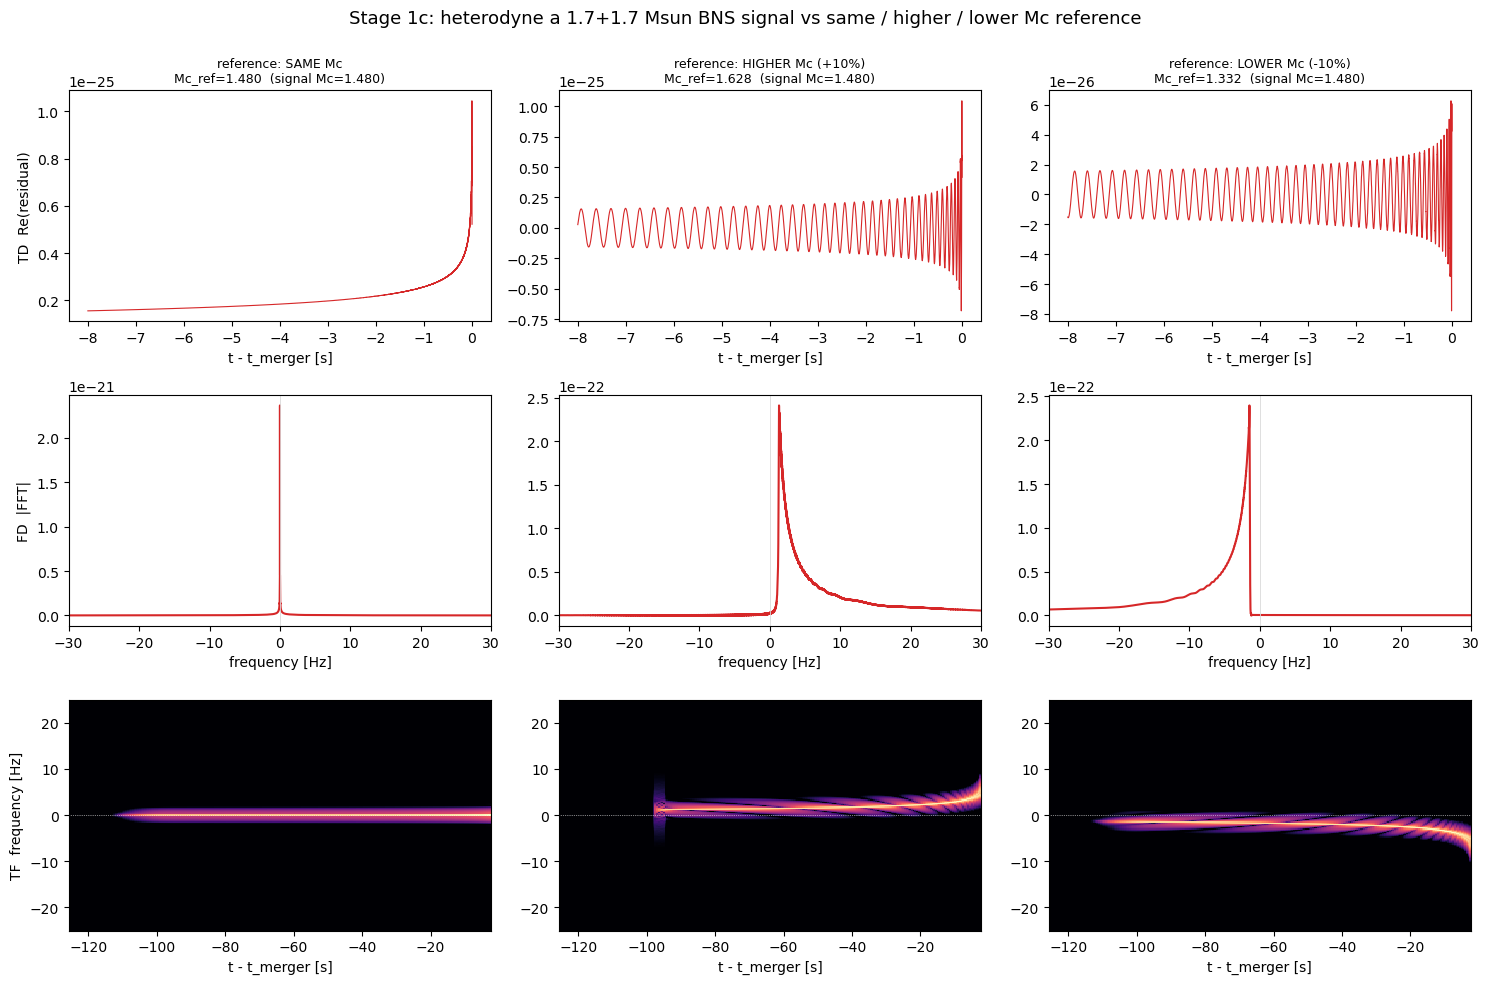

In [6]:
# ----------------------------------------------------------------------
# Stage 1c: heterodyne a real IMRPhenomXAS_NRTidalv3 BNS signal against
# references with the SAME / HIGHER / LOWER chirp mass (via mass scaling).
# Uses a compact 128 s demo segment.
# ----------------------------------------------------------------------
from scipy.signal import spectrogram
from sage.core.base_classes import BaseConfig, BaseDataConfig
from sage.core.config import register_configs
from sage.data.waveform.approximants.IMRPhenomXAS_NRTidalv3 import IMRPhenomXAS_NRTidalv3
from sage.data.waveform import taper as taper_mod
from sage.dsp.heterodyne import heterodyne
from sage.dsp.helpers import analytic_signal, instantaneous_frequency

SR = 2048.0
class _CfgC:
    batch_size = 2; device = "cpu"; dtype = torch.float64; autocast = False; class_balance = 0.5
class _DataCfgC:
    sample_rate = SR; signal_low_frequency_cutoff = 20.0; noise_low_frequency_cutoff = 15.0
    sample_length_in_s = 124.0; padding_length_in_s = 2.0          # -> 128 s padded segment
register_configs(BaseConfig(_CfgC()), BaseDataConfig(_DataCfgC()))

model = IMRPhenomXAS_NRTidalv3()               # FD-native generator on the 128 s grid
dt = 1.0 / SR
N_freq = model.n_pad + model.f_numel
N_time = 2 * (N_freq - 1)
tt = np.arange(N_time) * dt

def analytic_td(theta):
    """FD hp -> complex analytic time-domain signal (IFFT of the one-sided spectrum)."""
    hp, _ = model.get_hphc(theta, reproduce_lal=True)      # merger at the natural epoch (end)
    H = hp[0].clone()
    wtap = taper_mod.fd_low_freq_taper(model.f[0], 20.0, model.df, 200)   # clean low-f edge
    H[model.n_pad:] = H[model.n_pad:] * wtap.to(H.dtype)
    A = torch.zeros(N_time, dtype=torch.complex128)
    A[0] = H[0]; A[1:N_freq - 1] = 2.0 * H[1:N_freq - 1]; A[N_freq - 1] = H[N_freq - 1]
    return torch.fft.ifft(A).numpy()

# theta columns: [m1, m2, chi1z, chi2z, distance, tc, coa_phase, incl, lambda1, lambda2]
def make_theta(m1, m2, c1=0.0, c2=0.0, l1=0.0, l2=0.0):
    return torch.tensor([[m1, m2, c1, c2, 100.0, 0.0, 0.0, 0.0, l1, l2]], dtype=torch.float64)
def mchirp(m1, m2):
    return (m1 * m2) ** 0.6 / (m1 + m2) ** 0.2

# --- a BNS signal (any signal) ---
m1s, m2s = 1.7, 1.7
c1, c2, l1, l2 = 0.03, -0.02, 400.0, 600.0
Mc_s = mchirp(m1s, m2s)
z_sig = analytic_td(make_theta(m1s, m2s, c1, c2, l1, l2))
amp_sig = np.abs(z_sig); thr = 1e-3 * amp_sig.max()
t0 = np.where(amp_sig > thr)[0][0]; tmax = np.where(amp_sig > thr)[0][-1]   # signal support

# --- references: SAME / HIGHER (+10%) / LOWER (-10%) chirp mass via mass scaling ---
cases = [("reference: SAME Mc", 1.00),
         ("reference: HIGHER Mc (+10%)", 1.10),
         ("reference: LOWER Mc (-10%)", 0.90)]
freqs = np.fft.fftshift(np.fft.fftfreq(N_time, dt))
print("signal: %.1f+%.1f Msun,  chirp mass Mc = %.3f" % (m1s, m2s, Mc_s))

fig, ax = plt.subplots(3, 3, figsize=(15, 10))
for col, (name, k) in enumerate(cases):
    z_ref = analytic_td(make_theta(m1s * k, m2s * k, c1, c2, l1, l2))
    after = heterodyne(z_sig, z_ref)                      # residual: f_sig - f_ref
    mask = (amp_sig > thr) & (np.abs(z_ref) > thr)        # keep only where both have support
    after = np.where(mask, after, 0.0)
    Mc_ref = Mc_s * k

    ifr = instantaneous_frequency(after, dt)
    msg = "  %-27s Mc_ref=%.3f | residual IF" % (name, Mc_ref)
    for d in (30., 10., 3.):
        msg += "  (merger-%2.0fs)%+6.2f Hz" % (d, ifr[tmax - int(d / dt)])
    print(msg)

    # TD: Re(residual) over the last 8 s before merger
    w = (tt > tmax * dt - 8) & (tt <= tmax * dt) & mask
    ax[0, col].plot(tt[w] - tmax * dt, after.real[w], color='C3', lw=0.8)
    ax[0, col].set_title("%s\nMc_ref=%.3f  (signal Mc=%.3f)" % (name, Mc_ref, Mc_s), fontsize=9)
    ax[0, col].set_xlabel("t - t_merger [s]")
    if col == 0:
        ax[0, col].set_ylabel("TD  Re(residual)")

    # FD: two-sided residual spectrum
    Xa = np.fft.fftshift(np.abs(np.fft.fft(after)))
    ax[1, col].plot(freqs, Xa, color='C3'); ax[1, col].set_xlim(-30, 30)
    ax[1, col].axvline(0, color='0.85', lw=0.6); ax[1, col].set_xlabel("frequency [Hz]")
    if col == 0:
        ax[1, col].set_ylabel("FD  |FFT|")

    # TF: residual spectrogram (exclude last 0.5 s ringdown, normalise per-panel)
    end = tmax - int(0.5 / dt)
    fS, tS, S = spectrogram(after[t0:end], fs=SR, nperseg=8192, noverlap=7168,
                            detrend=False, return_onesided=False, scaling='spectrum')
    fS = np.fft.fftshift(fS); S = np.fft.fftshift(S, axes=0)
    SdB = 10 * np.log10(S / S.max() + 1e-12)
    ax[2, col].pcolormesh(tS - (end - t0) * dt, fS, SdB, shading='auto', cmap='magma',
                          vmin=-50, vmax=0)
    ax[2, col].set_ylim(-25, 25); ax[2, col].axhline(0, color='w', ls=':', lw=0.5)
    ax[2, col].set_xlabel("t - t_merger [s]")
    if col == 0:
        ax[2, col].set_ylabel("TF  frequency [Hz]")

fig.suptitle("Stage 1c: heterodyne a %.1f+%.1f Msun BNS signal vs same / higher / lower Mc reference"
             % (m1s, m2s), fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Stage 1d - decimation: how low a sample rate does the baseband need?

After heterodyning, the signal sits at DC and the only thing left to sample is
the **residual**. This is a **one-time, pre-training** calculation and we have
the *exact* waveforms, so we do **not** measure anything off the heterodyned
signal - the residual is computed analytically from the chirp. At
time-to-merger `tau`, `f(tau) = (1/pi)(5/(256 tau))^(3/8)(G Mc/c^3)^(-5/8)`, so
`residual(tau) = f_sig(tau) - f_ref(tau)`. Parametrised by the reference
frequency it is **linear**: `residual = f_ref * [(Mc_ref/Mc_sig)^(5/8) - 1]`.

The top panel shows the exact residual for the three references (same / higher /
lower Mc). It is **asymmetric** - the lower-Mc reference gives the larger `|B|`,
so it is the worst case. The residual diverges at merger, so we bound it by
keeping up to merger - 2 s (a stand-in for the Stage-4 early-warning truncation).

Given the two-sided worst-case half-bandwidth `B`, a complex baseband needs a
sample rate `>= 2B`; we take the next power of 2 above `2B x buffer`
(`sage.dsp.decimate.rate_and_factor`) and decimate with the half-band
anti-alias cascade in **`sage.dsp.decimate.decimate`** (a standalone module
built from the `MultirateSampler` kernel, DC-gain-1 so amplitude is preserved).
The bottom panels show the decimated baseband spectra: same -> DC, higher -> a
one-sided positive band, lower -> one-sided negative, all inside the new
`+/- fs/2` Nyquist.

**On the residual "going to slightly higher frequencies that seem ignored":**
the residual is largest near merger, where the signal amplitude is also largest,
so it appears as a high-frequency shoulder in the baseband spectrum. It is
**not** ignored - it is exactly what sets the sample rate (the Nyquist is chosen
*above* it). Any content *beyond* the residual band is spectral **leakage** from
the hard truncation edge (a rectangular cut at the highest-amplitude part of the
signal); the anti-alias filter removes it before decimating (so it never aliases
into the kept band), and tapering the truncation (the cosine window here) removes
it at the source - which is why the decimated spectra now cut off cleanly.

signal Mc = 1.480
  same Mc    Mc_ref=1.480   B = 0.00 Hz
  higher Mc  Mc_ref=1.628   B = 5.27 Hz
  lower Mc   Mc_ref=1.332   B = 6.20 Hz
worst-case B = 6.20 Hz  ->  Nyquist 2B = 12.4 Hz  ->  sample rate 32 Hz  (decimation x64)


[W708 14:49:09.060216687 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.114538892 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.154207130 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.176183403 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.178204896 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.179262233 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.248132195 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


[W708 14:49:09.302794583 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.341937799 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.346469761 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.348442791 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.353084640 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.415681901 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.471864024 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


[W708 14:49:09.511674938 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.515626404 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.517657200 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:49:09.518958775 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


samples/detector:  258047 @ 2048 Hz  ->  4032 @ 32 Hz  (x64 fewer)


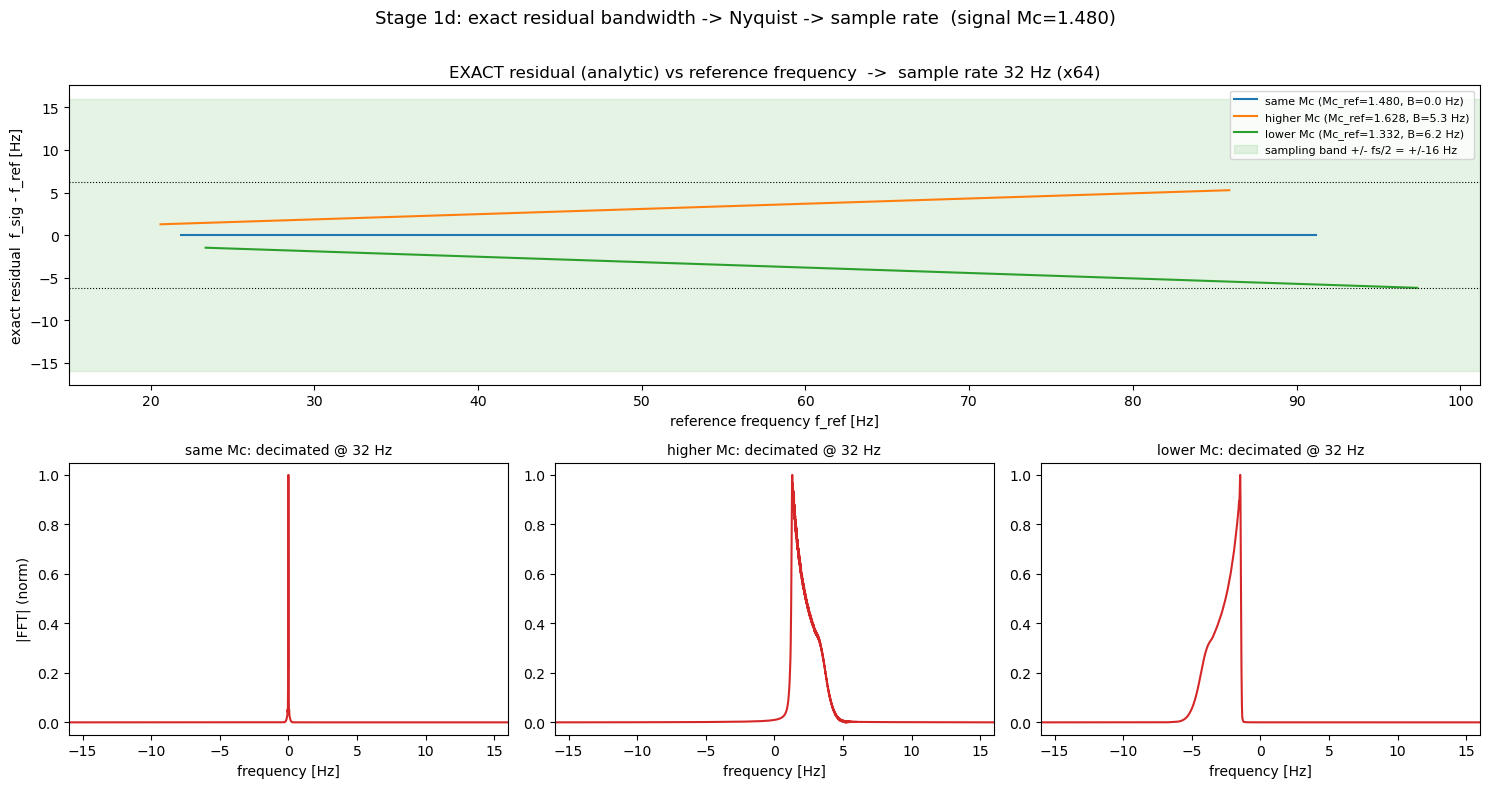

In [7]:
# ----------------------------------------------------------------------
# Stage 1d: once at DC, how low a sample rate does the baseband need?
# The residual is computed EXACTLY from the chirp (no measuring -- this is a
# one-time pre-training calculation and we have the exact waveforms).  Shown for
# all three references (same / higher / lower Mc): residual, Nyquist, sample
# rate.  Decimation uses the new sage.dsp.decimate module.
# (reuses the Stage-1c signal z_sig / model / helpers)
# ----------------------------------------------------------------------
import warnings; warnings.filterwarnings('ignore')          # quiet NNPACK conv1d notices
from scipy.signal.windows import tukey
from sage.dsp.decimate import decimate, rate_and_factor
MSUN_S = 4.925491025873693e-6

def f_of_tau(Mc, tau):        # leading-order GW frequency at time-to-merger tau [s]
    return (1.0 / np.pi) * (5.0 / (256.0 * tau)) ** (3.0 / 8.0) * (Mc * MSUN_S) ** (-5.0 / 8.0)

TAU_MIN = 2.0                 # bound the residual by keeping up to merger - TAU_MIN
end = tmax - int(TAU_MIN / dt)
cases = [("same Mc", 1.00), ("higher Mc", 1.10), ("lower Mc", 0.90)]

# (1) EXACT residual bandwidth per case (analytic): residual(tau) = f_sig - f_ref,
#     max at the truncation (tau = TAU_MIN).  No signal is generated or measured here.
B = {name: abs(f_of_tau(Mc_s, TAU_MIN) - f_of_tau(Mc_s * k, TAU_MIN)) for name, k in cases}
Bworst = max(B.values())
rate, factor = rate_and_factor(Bworst, SR, buffer=1.5)
print("signal Mc = %.3f" % Mc_s)
for name, k in cases:
    print("  %-10s Mc_ref=%.3f   B = %.2f Hz" % (name, Mc_s * k, B[name]))
print("worst-case B = %.2f Hz  ->  Nyquist 2B = %.1f Hz  ->  sample rate %d Hz  (decimation x%d)"
      % (Bworst, 2 * Bworst, rate, factor))

# (2) decimate each case with sage.dsp.decimate (taper the truncation to limit leakage)
decs = {}
for name, k in cases:
    z_ref = analytic_td(make_theta(m1s * k, m2s * k, c1, c2, l1, l2))
    after = heterodyne(z_sig, z_ref)
    mask = (amp_sig > thr) & (np.abs(z_ref) > thr)
    after = np.where(mask, after, 0.0)
    t0c = np.where(mask)[0][0]
    seg = after[t0c:end] * tukey(end - t0c, 0.08)          # cosine-taper both edges
    decs[name] = decimate(seg, factor)                     # <- sage.dsp.decimate
print("samples/detector:  %d @ %.0f Hz  ->  %d @ %d Hz  (x%d fewer)"
      % (end - t0c, SR, len(decs['same Mc']), rate, factor))

# (3) plot: exact residual (3 cases) + decimated baseband spectra
fig = plt.figure(figsize=(15, 8)); gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 1])
axT = fig.add_subplot(gs[0, :])
taus = np.logspace(np.log10(TAU_MIN), np.log10(90.0), 400)
for name, k in cases:
    fref = f_of_tau(Mc_s * k, taus)
    axT.plot(fref, f_of_tau(Mc_s, taus) - fref,
             label="%s (Mc_ref=%.3f, B=%.1f Hz)" % (name, Mc_s * k, B[name]))
axT.axhspan(-rate / 2, rate / 2, color='C2', alpha=0.12,
            label='sampling band +/- fs/2 = +/-%g Hz' % (rate / 2))
axT.axhline(Bworst, color='k', ls=':', lw=0.8); axT.axhline(-Bworst, color='k', ls=':', lw=0.8)
axT.set_xlabel('reference frequency f_ref [Hz]'); axT.set_ylabel('exact residual  f_sig - f_ref [Hz]')
axT.set_title('EXACT residual (analytic) vs reference frequency  ->  sample rate %d Hz (x%d)' % (rate, factor))
axT.legend(fontsize=8); axT.set_xlim(15, None)
for col, (name, k) in enumerate(cases):
    d = decs[name]
    fD = np.fft.fftshift(np.fft.fftfreq(len(d), 1 / rate)); XD = np.fft.fftshift(np.abs(np.fft.fft(d)))
    ax = fig.add_subplot(gs[1, col])
    ax.plot(fD, XD / (XD.max() + 1e-30), 'C3')
    ax.axvline(rate / 2, color='k', ls=':', lw=0.7); ax.axvline(-rate / 2, color='k', ls=':', lw=0.7)
    ax.set_xlim(-rate / 2, rate / 2); ax.set_xlabel('frequency [Hz]')
    ax.set_title('%s: decimated @ %d Hz' % (name, rate), fontsize=10)
    if col == 0:
        ax.set_ylabel('|FFT| (norm)')
fig.suptitle('Stage 1d: exact residual bandwidth -> Nyquist -> sample rate  (signal Mc=%.3f)' % Mc_s,
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

## Stage 1e - choosing the reference from the prior (a minimax problem)

This stage does ONE thing: pick the single fixed heterodyne reference from the
broad prior. Everything is computed from exact generator waveforms, once,
before training.

### How the residual is calculated, exactly

After heterodyning, the baseband phase is `phi_sig(t) - phi_ref(t)`, so the
residual instantaneous frequency is simply

    residual_s(tau) = f_s(tau) - f_ref(tau)

where `f(tau)` is a system's instantaneous GW frequency at time-to-merger
`tau`. We therefore need each prior system's **time-frequency track** exactly.

The generator outputs `h(f) = A(f) e^{i phi(f)}` in the frequency domain. A
chirp sweeps through each frequency once, at a specific time `t*(f)`; near
that moment the signal is locally monochromatic, so its contribution to the
Fourier integral at `f` concentrates there (stationary phase). The FD phase
therefore *encodes the arrival time of every frequency* — recovered by the
group delay:

    t(f) = -(1/2pi) * d(phi)/df

Differentiating the **exact model phase** gives the exact track — every PN
order, spin and tidal effect in `IMRPhenomXAS_NRTidalv3` included; nothing is
fitted or measured off time series. Two implementation details matter
(`sage/dsp/reference.py::time_frequency_track`):

1. **Unwrap aliasing.** Numerical unwrapping needs `|dphi| < pi` between grid
   points; since `dphi = 2pi t(f) df`, it fails once `|t(f)| > 1/(2 df) = T/2
   = 147.5 s`. Light systems last up to ~453 s. Fix: subtract the *analytic
   0PN phase* (closed form, exactly known), unwrap the tiny remainder, add the
   0PN group delay back. Exact for arbitrarily long signals.
2. **Merger cap.** Beyond the merger the model phase is taper/clamp
   machinery, not physics; the track is inverted to `f(tau)` only below the
   model's own tidal merger frequency (`merger_frequency`).

Validation against the 0PN closed form: median difference 0.3 Hz, growing to
~4 Hz at corner spins/tides — small, but exactly the reason the *exact* track
is used for selection rather than the 0PN formula.

### How the minimax solving works

Both `f_s` and `f_ref` scale like `tau^{-3/8}`, so `|residual_s(tau)|` grows
monotonically toward merger: **the worst residual over the kept span occurs at
the truncation `tau_min`**. The bandwidth the pipeline must keep for reference
choice `R` is therefore

    B(R) = max over prior s of | f_s(tau_min) - f_R(tau_min) |

and we want the `R` minimising it — a classic 1-D **minimax (Chebyshev
center)** problem: for points on a line, the point minimising the maximum
distance is the *midpoint of the two extremes*, and the optimal value is half
the range:

    f_R*(tau_min) = (max_s f_s + min_s f_s)/2 ,     B* = (max_s f_s - min_s f_s)/2

Two consequences worth internalising:

- **only the prior extremes matter** — the objective `B(R)` is the maximum of
  two straight lines in `f_R` (a V shape, third panel); interior systems never
  bind;
- **the optimum is NOT the median system**: `f ∝ Mc^(-5/8)` is convex, so the
  frequency midpoint maps to a chirp mass well below the median Mc — a
  median-Mc reference wastes band on the light side (marker in the third
  panel).

Finally, the reference *system*: we need the equal-mass zero-spin template
whose exact `f(tau_min)` equals `f_R*`. Since `f(tau_min; Mc)` is monotone
(≈ `Mc^(-5/8)`), `select_reference` root-finds on the exact generator with a
0PN-scaled fixed point, `Mc <- Mc * (f_now/f_target)^(8/5)`, converging in 2-4
generator calls.

The plots: (1) every prior system's exact `f(tau)` curve with the chosen
reference highlighted; (2) the same curves *after* heterodyning (the residual
fan) bounded by ±B* at `tau_min`; (3) the minimax objective `B(Mc_ref)` with
its minimum at the selected reference.

exact f(tau) curves: 134 systems, one generation each, 24 s


f(tau_min=10 s) over the prior: [35.02, 83.96] Hz
  lightest -> HIGHEST f, binds high edge: Mc=0.653  chi=(+0.25,+0.25)
  heaviest -> LOWEST  f, binds low  edge: Mc=2.612  chi=(+0.00,+0.00)
Chebyshev midpoint  f_mid = 59.49 Hz   ->   B* = 24.47 Hz (two-sided +/-)
solved on the exact generator: Mc_ref = 1.1290  (equal-mass 1.297 + 1.297 Msun, chi=0, Lambda=0)


naive median-Mc reference (Mc=1.565): B = 35.45 Hz  ->  minimax saves 31% of band


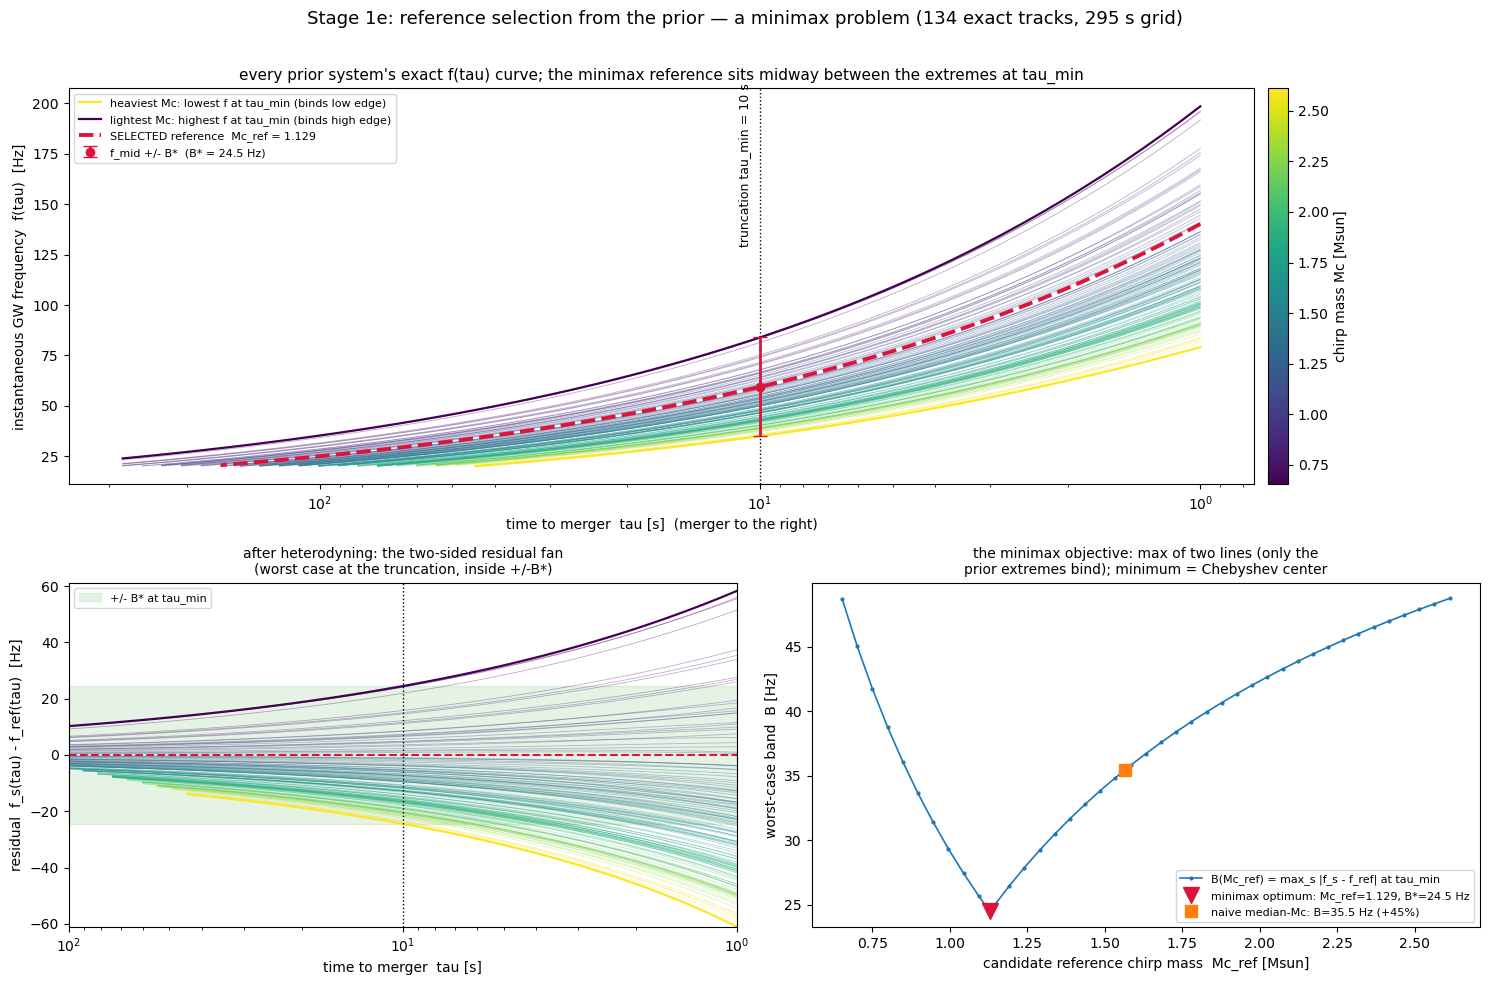

In [8]:
# ----------------------------------------------------------------------
# Stage 1e: reference selection from the prior (minimax), nothing else.
# Exact f(tau) curves for every prior system -> Chebyshev midpoint at the
# truncation -> solve the reference chirp mass on the exact generator.
# ----------------------------------------------------------------------
import time
from sage.data.waveform.sampler import read_from_config
from sage.dsp.reference import (freq_at_tau_batch, select_reference,
                                mchirp as _mch, mc_to_equal_mass)

# production grid: 287 + 2x4 = 295 s; batched generator (B = 16)
class _CfgE:
    batch_size = 32; device = "cpu"; dtype = torch.float64; autocast = False; class_balance = 0.5
class _DataCfg295:
    sample_rate = SR; signal_low_frequency_cutoff = 20.0; noise_low_frequency_cutoff = 15.0
    sample_length_in_s = 287.0; padding_length_in_s = 4.0
register_configs(BaseConfig(_CfgE()), BaseDataConfig(_DataCfg295()))
model295 = IMRPhenomXAS_NRTidalv3()
NT295 = 2 * (model295.n_pad + model295.f_numel - 1)

# --- prior systems: sage sampler draws + explicit corners ---------------------
sampler_e = read_from_config(str(REPO / 'runs/bns/gwconfig_ewbroad.yaml'), seed=11)
be = sampler_e(128)
_cols = ['mass1','mass2','chi1z','chi2z','distance','tc','coa_phase','inclination','lambda1','lambda2']
th_prior = be[:, [sampler_e.param_index[c] for c in _cols]].to(torch.float64)
th_prior[:, 5] = 0.0                                    # tc=0: aligned mergers

def _row(m1, m2, c1=0., c2=0., l1=0., l2=0.):
    return torch.tensor([[m1, m2, c1, c2, 100., 0., 0., 0., l1, l2]], dtype=torch.float64)
corners = torch.cat([
    _row(0.75, 0.75, +0.25, +0.25), _row(0.75, 0.75, -0.25, -0.25),
    _row(0.75, 0.75, 0., 0., 15000., 15000.), _row(3.0, 3.0, +0.25, +0.25),
    _row(3.0, 3.0, -0.25, -0.25),   _row(3.0, 3.0, 0., 0., 15000., 15000.),
])
th_all = torch.cat([corners, th_prior])
Mc_all = np.array([_mch(float(r[0]), float(r[1])) for r in th_all])

# --- exact f(tau) curve for EVERY system (one generation each, batched) -------
TAU_EW = 10.0                                          # early-warning truncation
TAU_GRID = np.unique(np.concatenate([np.geomspace(1.0, 280.0, 56), [1., 2., 5., 10.]]))
I10 = int(np.where(np.isclose(TAU_GRID, TAU_EW))[0][0])
t0e = time.time()
F_CURVES = freq_at_tau_batch(model295, th_all, TAU_GRID)         # (N, len(TAU_GRID))
F_CURVES = np.where(F_CURVES <= float(model295.f[0, 0]) + 0.05, np.nan, F_CURVES)
print("exact f(tau) curves: %d systems, one generation each, %.0f s"
      % (F_CURVES.shape[0], time.time() - t0e))

# --- minimax selection at the truncation --------------------------------------
f_trunc = F_CURVES[:, I10]
REF = select_reference(model295, th_all, TAU_EW, f_trunc=f_trunc)
print("f(tau_min=%g s) over the prior: [%.2f, %.2f] Hz" % (TAU_EW, f_trunc.min(), f_trunc.max()))
print("  lightest -> HIGHEST f, binds high edge: Mc=%.3f  chi=(%+.2f,%+.2f)" %
      (Mc_all[REF['i_hi']], th_all[REF['i_hi'], 2], th_all[REF['i_hi'], 3]))
print("  heaviest -> LOWEST  f, binds low  edge: Mc=%.3f  chi=(%+.2f,%+.2f)" %
      (Mc_all[REF['i_lo']], th_all[REF['i_lo'], 2], th_all[REF['i_lo'], 3]))
print("Chebyshev midpoint  f_mid = %.2f Hz   ->   B* = %.2f Hz (two-sided +/-)" % (REF['f_mid'], REF['B']))
print("solved on the exact generator: Mc_ref = %.4f  (equal-mass %.3f + %.3f Msun, chi=0, Lambda=0)"
      % (REF['mc_ref'], REF['m_ref'], REF['m_ref']))

# reference curve + minimax objective sweep (all exact, batched)
th_ref_curve = REF['theta_ref']
F_REF = freq_at_tau_batch(model295, th_ref_curve, TAU_GRID)[0]
F_REF = np.where(F_REF <= float(model295.f[0, 0]) + 0.05, np.nan, F_REF)

Mc_med = float(np.median(Mc_all))
MC_SWEEP = np.unique(np.append(np.linspace(Mc_all.min(), Mc_all.max(), 41), [Mc_med, REF['mc_ref']]))
th_sweep = torch.cat([_row(mc_to_equal_mass(m), mc_to_equal_mass(m)) for m in MC_SWEEP])
F_SWEEP = freq_at_tau_batch(model295, th_sweep, [TAU_EW])[:, 0]
B_SWEEP = np.array([np.abs(f_trunc - fr).max() for fr in F_SWEEP])
B_med = float(B_SWEEP[np.argmin(np.abs(MC_SWEEP - Mc_med))])
print("naive median-Mc reference (Mc=%.3f): B = %.2f Hz  ->  minimax saves %.0f%% of band"
      % (Mc_med, B_med, 100 * (1 - REF['B'] / B_med)))

# ----------------------------------------------------------------------
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1])
cmap = plt.get_cmap('viridis')
cnorm = plt.Normalize(Mc_all.min(), Mc_all.max())

# (1) all prior curves + highlighted reference
ax1 = fig.add_subplot(gs[0, :])
for i in range(F_CURVES.shape[0]):
    ax1.plot(TAU_GRID, F_CURVES[i], lw=0.6, alpha=0.35, color=cmap(cnorm(Mc_all[i])))
ax1.plot(TAU_GRID, F_CURVES[REF['i_lo']], lw=1.6, color=cmap(cnorm(Mc_all[REF['i_lo']])),
         label='heaviest Mc: lowest f at tau_min (binds low edge)')
ax1.plot(TAU_GRID, F_CURVES[REF['i_hi']], lw=1.6, color=cmap(cnorm(Mc_all[REF['i_hi']])),
         label='lightest Mc: highest f at tau_min (binds high edge)')
ax1.plot(TAU_GRID, F_REF, lw=2.8, color='crimson', ls='--',
         label='SELECTED reference  Mc_ref = %.3f' % REF['mc_ref'])
ax1.axvline(TAU_EW, color='k', lw=1, ls=':')
ax1.annotate('truncation tau_min = %g s' % TAU_EW, xy=(TAU_EW, 150), fontsize=9, rotation=90,
             xytext=(TAU_EW * 1.12, 130))
ax1.errorbar([TAU_EW], [REF['f_mid']], yerr=[[REF['B']], [REF['B']]], fmt='o', color='crimson',
             capsize=5, lw=2, label='f_mid +/- B*  (B* = %.1f Hz)' % REF['B'])
ax1.set_xscale('log'); ax1.invert_xaxis()
ax1.set_xlabel('time to merger  tau [s]  (merger to the right)')
ax1.set_ylabel('instantaneous GW frequency  f(tau)  [Hz]')
ax1.set_title('every prior system\'s exact f(tau) curve; the minimax reference sits midway '
              'between the extremes at tau_min', fontsize=11)
ax1.legend(fontsize=8, loc='upper left')
fig.colorbar(plt.cm.ScalarMappable(norm=cnorm, cmap=cmap), ax=ax1, label='chirp mass Mc [Msun]', pad=0.01)

# (2) the residual fan: same curves after heterodyning against the reference
ax2 = fig.add_subplot(gs[1, 0])
for i in range(F_CURVES.shape[0]):
    ax2.plot(TAU_GRID, F_CURVES[i] - F_REF, lw=0.6, alpha=0.35, color=cmap(cnorm(Mc_all[i])))
ax2.plot(TAU_GRID, F_CURVES[REF['i_lo']] - F_REF, lw=1.6, color=cmap(cnorm(Mc_all[REF['i_lo']])))
ax2.plot(TAU_GRID, F_CURVES[REF['i_hi']] - F_REF, lw=1.6, color=cmap(cnorm(Mc_all[REF['i_hi']])))
ax2.axhline(0, color='crimson', lw=1.5, ls='--')
ax2.axvline(TAU_EW, color='k', lw=1, ls=':')
ax2.axhspan(-REF['B'], REF['B'], color='C2', alpha=0.12, label='+/- B* at tau_min')
ax2.set_xscale('log'); ax2.invert_xaxis(); ax2.set_xlim(100, 1)
ax2.set_ylim(-2.5 * REF['B'], 2.5 * REF['B'])
ax2.set_xlabel('time to merger  tau [s]'); ax2.set_ylabel('residual  f_s(tau) - f_ref(tau)  [Hz]')
ax2.set_title('after heterodyning: the two-sided residual fan\n(worst case at the truncation, inside +/-B*)',
              fontsize=10)
ax2.legend(fontsize=8)

# (3) the minimax objective B(Mc_ref): V-shaped, minimum at the selection
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(MC_SWEEP, B_SWEEP, 'C0.-', lw=1.2, ms=4, label='B(Mc_ref) = max_s |f_s - f_ref| at tau_min')
ax3.plot([REF['mc_ref']], [REF['B']], 'v', color='crimson', ms=11,
         label='minimax optimum: Mc_ref=%.3f, B*=%.1f Hz' % (REF['mc_ref'], REF['B']))
ax3.plot([Mc_med], [B_med], 's', color='C1', ms=9,
         label='naive median-Mc: B=%.1f Hz (+%.0f%%)' % (B_med, 100 * (B_med / REF['B'] - 1)))
ax3.set_xlabel('candidate reference chirp mass  Mc_ref [Msun]')
ax3.set_ylabel('worst-case band  B [Hz]')
ax3.set_title('the minimax objective: max of two lines (only the\nprior extremes bind); minimum = Chebyshev center',
              fontsize=10)
ax3.legend(fontsize=8)
fig.suptitle('Stage 1e: reference selection from the prior — a minimax problem (%d exact tracks, 295 s grid)'
             % F_CURVES.shape[0], fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

## Stage 1f - the full framework, end to end, and proof of no information loss

The complete chain, applied to real prior signals against the **single fixed
auto-selected reference** from Stage 1e:

    generate (FD, 295 s) -> IFFT to analytic TD -> heterodyne vs FIXED reference
    -> truncate at t_c - 10 s -> Tukey taper -> anti-alias decimate to 64 Hz
    -> [network input]

Two practical details, both physical:
- the **reference** is generated with its band edge lowered (~15 Hz grid) and
  entry-tapered so its own time-domain realisation spans every signal without
  wrap-around;
- each **signal** is entry-tapered at the frequency where its remaining
  duration equals the analysis span (270 s), because a signal longer than the
  window (possible below 1.0 Msun) contributes only its final window anyway —
  a finite observation window does exactly this.

**Proof protocol (no information loss).** The decimated stream is inverted:
FFT zero-pad upsampling (periodic sinc interpolation) back to 2048 Hz, and
compared against the original kept baseband segment with the complex match
`M = |<a, r>| / (|a||r|)` (flat PSD = whitened-domain inner product; the
re-modulation `e^{+i Phi_ref}` cancels identically in `M`, so baseband
comparison is exact). `M` is the fraction of optimal SNR retained: `M = 1`
means the decimated representation carries the same information as the full
2048 Hz stream. Two controls make the test sharp:

- **positive**: mismatch `1 - M` should sit at the anti-alias filter's design
  floor (~1e-8 for the 63-tap Kaiser at 90 dB), for EVERY prior draw
  including the corners;
- **negative**: decimating 4x deeper than the Nyquist criterion allows must
  destroy the match — proving the metric actually detects information loss.

tau_min= 1.0 s | B*=59.68 Hz | Mc_ref=1.1468 | rate  256 Hz (x8)


tau_min= 2.0 s | B*=45.43 Hz | Mc_ref=1.1368 | rate  128 Hz (x16)


tau_min= 5.0 s | B*=31.89 Hz | Mc_ref=1.1308 | rate  128 Hz (x16)
tau_min=10.0 s | B*=24.47 Hz | Mc_ref=1.1290 | rate   64 Hz (x32)

ADOPTED (early warning): tau_min = 10 s, B* = 24.47 Hz -> rate 64 Hz (x32 from 2048 Hz)
margins inside the 1.25 buffer: tc jitter +/-0.25 s ~ 0.8 Hz, 10 ms detector delay ~ 0.03 Hz


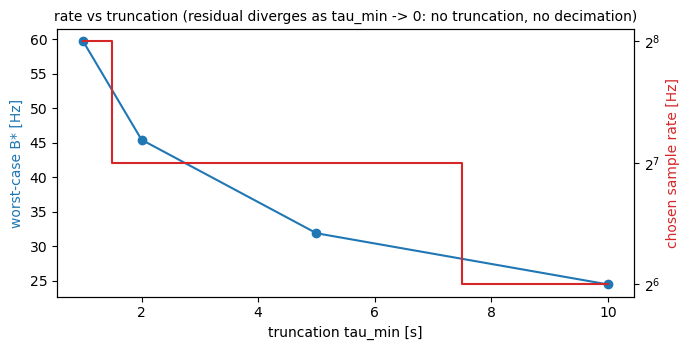

In [9]:
# ----------------------------------------------------------------------
# Stage 1f setup: robust decimation rate vs truncation (uses the Stage-1e
# tracks; the reference re-selected per tau_min), then adopt tau_min = 10 s.
# ----------------------------------------------------------------------
RATE_TABLE = {}
for tau in (1.0, 2.0, 5.0, 10.0):
    j = int(np.where(np.isclose(TAU_GRID, tau))[0][0])
    ref_t = REF if tau == TAU_EW else select_reference(model295, th_all, tau, f_trunc=F_CURVES[:, j])
    rate_t, factor_t = rate_and_factor(ref_t['B'], SR, buffer=1.25)
    RATE_TABLE[tau] = (ref_t['B'], rate_t, factor_t)
    print("tau_min=%4.1f s | B*=%5.2f Hz | Mc_ref=%.4f | rate %4d Hz (x%d)"
          % (tau, ref_t['B'], ref_t['mc_ref'], rate_t, factor_t))

RATE_EW, FACTOR_EW = RATE_TABLE[TAU_EW][1], RATE_TABLE[TAU_EW][2]
print("\nADOPTED (early warning): tau_min = %g s, B* = %.2f Hz -> rate %d Hz (x%d from %d Hz)"
      % (TAU_EW, REF['B'], RATE_EW, FACTOR_EW, SR))
print("margins inside the 1.25 buffer: tc jitter +/-0.25 s ~ %.1f Hz, 10 ms detector delay ~ %.2f Hz"
      % (0.375 * 0.25 / TAU_EW * REF['f_trunc'].max(),
         0.375 * REF['f_trunc'].max() / TAU_EW * 0.01))

fig, axr = plt.subplots(1, 1, figsize=(7, 3.6))
taus_r = sorted(RATE_TABLE)
axr.plot(taus_r, [RATE_TABLE[t][0] for t in taus_r], 'o-', color='C0')
axr.set_xlabel('truncation tau_min [s]'); axr.set_ylabel('worst-case B* [Hz]', color='C0')
axr2 = axr.twinx()
axr2.step(taus_r, [RATE_TABLE[t][1] for t in taus_r], where='mid', color='C3')
axr2.set_ylabel('chosen sample rate [Hz]', color='C3'); axr2.set_yscale('log', base=2)
axr.set_title('rate vs truncation (residual diverges as tau_min -> 0: no truncation, no decimation)',
              fontsize=10)
fig.tight_layout(); plt.show()

fixed reference: Mc=1.1290, entry 17.0 Hz, spans 290 s of the window


[W708 14:50:11.683209871 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:11.815293034 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


[W708 14:50:11.892244358 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:11.936492352 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:11.960423157 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


asymmetric mid  1.6+1.1, chi=(+0.15,-0.05), L=(300,800) | kept 285.0 s |  583672 -> 18240 samples | mismatch 1.48e-08


[W708 14:50:11.124555742 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:11.254277799 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


[W708 14:50:11.330391700 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:11.373278578 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:11.397439970 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


lightest corner 0.75+0.75, chi=+0.25                 | kept 285.0 s |  583646 -> 18239 samples | mismatch 2.16e-08


[W708 14:50:12.564846420 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:12.698857213 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:12.765813485 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


[W708 14:50:12.804316173 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:12.825561112 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


heaviest corner 3.0+3.0, chi=-0.25                   | kept 285.0 s |  583676 -> 18240 samples | mismatch 2.70e-08


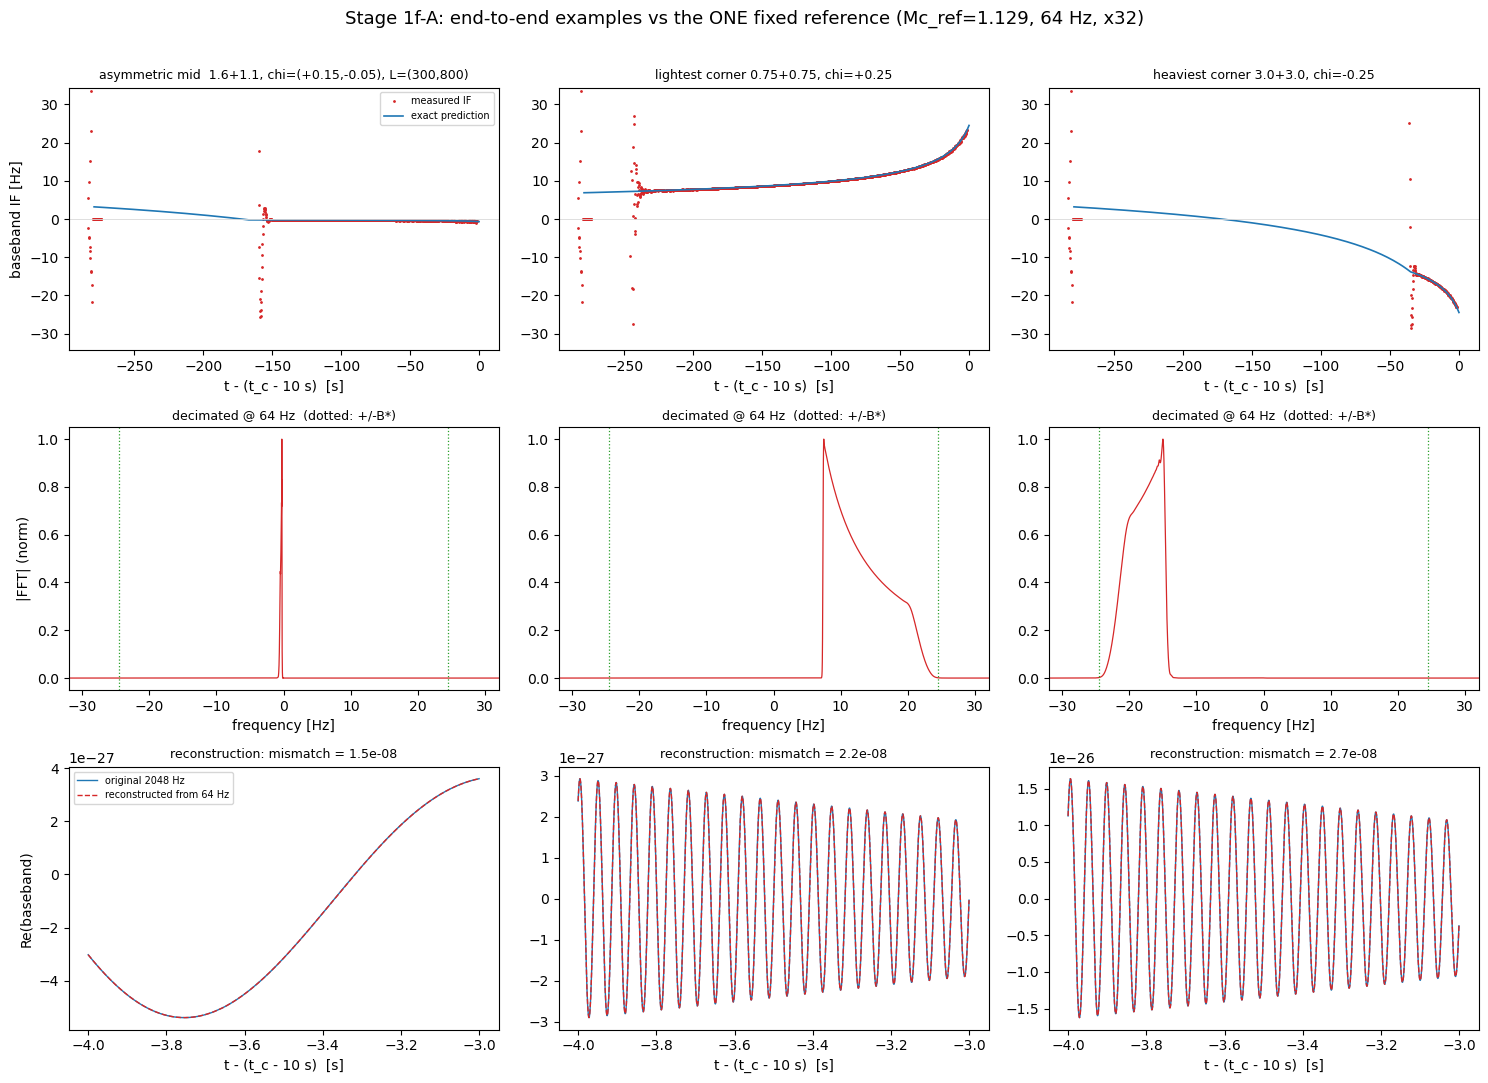

In [10]:
# ----------------------------------------------------------------------
# Stage 1f (A): the framework end to end, VISIBLY, on three real systems
# against the single fixed auto-selected reference.
# ----------------------------------------------------------------------
from sage.dsp.reference import time_frequency_track, invert_track, merger_frequency

# --- reference model on a 15 Hz band edge (same 295 s padded grid) -----------
class _DataCfgRef295:
    sample_rate = SR; signal_low_frequency_cutoff = 15.0; noise_low_frequency_cutoff = 15.0
    sample_length_in_s = 287.0; padding_length_in_s = 4.0
register_configs(BaseConfig(_CfgE()), BaseDataConfig(_DataCfgRef295()))
model_ref295 = IMRPhenomXAS_NRTidalv3()
assert 2 * (model_ref295.n_pad + model_ref295.f_numel - 1) == NT295

dt295 = 1.0 / SR
T_FIT = 270.0            # a signal may occupy at most this much of the window
TAU_MIN_EW = TAU_EW      # 10 s early-warning truncation (Stage 1e)

def gen_H(model_, thetas):
    """Batched FD generation -> full padded one-sided spectra (N, NF)."""
    N = thetas.shape[0]; B = model_.B; out = []
    for s in range(0, N, B):
        chunk = thetas[s:s + B]; n = chunk.shape[0]
        if n < B:
            chunk = torch.cat([chunk, chunk[-1:].expand(B - n, -1)], dim=0)
        hp, _ = model_.get_hphc(chunk, reproduce_lal=True)
        out.append(hp[:n].clone())
    return torch.cat(out, dim=0)

def analytic_td_H(model_, H_row, f_lo_taper, width_hz=1.0):
    """One-sided padded spectrum -> analytic TD signal, with entry taper."""
    H = H_row.clone()
    wbins = max(8, int(round(width_hz / float(model_.df))))
    w = taper_mod.fd_low_freq_taper(model_.f[0], f_lo_taper, model_.df, wbins)
    H[model_.n_pad:] = H[model_.n_pad:] * w.to(H.dtype)
    nf = H.shape[0]
    A = torch.zeros(NT295, dtype=torch.complex128)
    A[0] = H[0]; A[1:nf - 1] = 2.0 * H[1:nf - 1]; A[nf - 1] = H[nf - 1]
    return torch.fft.ifft(A).numpy()

def f_at_taus_from_H(model_, H_row, th, taus):
    """Exact f(tau) reusing an already-generated spectrum (no regeneration)."""
    f_grid = model_.f[0].numpy()
    hb = H_row.numpy()[model_.n_pad:]
    mc = _mch(float(th[0, 0]), float(th[0, 1]))
    tf = time_frequency_track(hb, f_grid, mc)
    return invert_track(tf, f_grid, merger_frequency(model_, th), taus)

# --- the ONE fixed reference: entry-tapered to fit the window ----------------
H_ref = gen_H(model_ref295, REF['theta_ref'])[0]
f_edge_ref = float(f_at_taus_from_H(model_ref295, H_ref, REF['theta_ref'], [280.0])[0])
z_ref295 = analytic_td_H(model_ref295, H_ref, f_lo_taper=max(15.2, f_edge_ref), width_hz=0.5)
ref_support = np.abs(z_ref295) > 1e-4 * np.abs(z_ref295).max()
print("fixed reference: Mc=%.4f, entry %.1f Hz, spans %.0f s of the window"
      % (REF['mc_ref'], max(15.2, f_edge_ref), ref_support.sum() * dt295))

def run_chain(th, H_row, factor, collect=False):
    """generate->heterodyne->truncate->taper->decimate->reconstruct->match."""
    fa = f_at_taus_from_H(model295, H_row, th, [T_FIT])
    f_entry = max(20.0, float(fa[0]) + 0.5)
    z = analytic_td_H(model295, H_row, f_lo_taper=f_entry, width_hz=1.0)
    # merger sits at the natural epoch ~ the segment end; large-Lambda systems
    # can overshoot the cyclic boundary by a few ms, wrapping the peak to t~0.
    # The IFFT is circular, so read the peak index wrap-aware.
    ipk = int(np.argmax(np.abs(z)))
    if ipk < NT295 // 2:
        ipk += NT295
    end = ipk - int(TAU_MIN_EW / dt295)                  # keep t <= t_c - 10 s
    assert 0 < end <= NT295, (ipk, end)
    start = int(np.argmax(np.abs(z[:end]) > 1e-3 * np.abs(z[:end]).max()))
    b = heterodyne(z[start:end], z_ref295[start:end])
    b = np.where(ref_support[start:end], b, 0.0)
    a = b * tukey(end - start, 0.05)                     # kept baseband @ 2048 Hz
    d = decimate(a, factor)                              # anti-alias + downsample
    # reconstruct: FFT zero-pad upsample (periodic sinc interpolation)
    D = np.fft.fft(d); h = len(d) // 2
    R = np.zeros(len(d) * factor, dtype=complex)
    R[:h] = D[:h]; R[-(len(d) - h):] = D[h:]
    r = (np.fft.ifft(R) * factor)[:len(a)]
    M = abs(np.vdot(a, r)) / (np.linalg.norm(a) * np.linalg.norm(r) + 1e-300)
    if collect:
        return M, a, d, r, start, end
    return M

# --- three visible examples: mid asymmetric + the two prior extremes ---------
ex_thetas = [
    ("asymmetric mid  1.6+1.1, chi=(+0.15,-0.05), L=(300,800)", _row(1.6, 1.1, 0.15, -0.05, 300., 800.)),
    ("lightest corner 0.75+0.75, chi=+0.25",                    _row(0.75, 0.75, 0.25, 0.25)),
    ("heaviest corner 3.0+3.0, chi=-0.25",                      _row(3.0, 3.0, -0.25, -0.25)),
]
H_ex = gen_H(model295, torch.cat([t for _, t in ex_thetas]))

fig, ax = plt.subplots(3, 3, figsize=(15, 11))
for col, ((name, th), H_row) in enumerate(zip(ex_thetas, H_ex)):
    M, a, d, r, start, end = run_chain(th, H_row, FACTOR_EW, collect=True)
    tt_k = (np.arange(len(a)) + start) * dt295
    t_end = end * dt295
    # row 0: baseband instantaneous frequency (measured) vs exact prediction.
    # Kept-segment time t maps to time-to-merger tau = (t_end - t) + tau_min.
    ifr = instantaneous_frequency(a, dt295)
    sl = slice(len(a) // 200, -max(1, len(a) // 200), 400)
    ax[0, col].plot(tt_k[:-1][sl] - t_end, ifr[sl], '.', ms=2, color='C3', label='measured IF')
    tau_span = (end - start) * dt295
    taus_pred = np.linspace(TAU_MIN_EW, TAU_MIN_EW + tau_span * 0.98, 200)
    f_sig_pred = f_at_taus_from_H(model295, H_row, th, taus_pred)
    f_ref_pred = f_at_taus_from_H(model_ref295, H_ref, REF['theta_ref'], taus_pred)
    ax[0, col].plot(-(taus_pred - TAU_MIN_EW), f_sig_pred - f_ref_pred, 'C0', lw=1.2,
                    label='exact prediction')
    ax[0, col].axhline(0, color='0.85', lw=0.6)
    ax[0, col].set_ylim(-1.2 * REF['B'] - 5, 1.2 * REF['B'] + 5)
    ax[0, col].set_title(name, fontsize=9); ax[0, col].set_xlabel('t - (t_c - 10 s)  [s]')
    if col == 0:
        ax[0, col].set_ylabel('baseband IF [Hz]'); ax[0, col].legend(fontsize=7)
    # row 1: decimated spectrum inside the new Nyquist
    fD = np.fft.fftshift(np.fft.fftfreq(len(d), 1 / RATE_EW))
    XD = np.fft.fftshift(np.abs(np.fft.fft(d)))
    ax[1, col].plot(fD, XD / XD.max(), 'C3', lw=0.9)
    for x0 in (-REF['B'], REF['B']):
        ax[1, col].axvline(x0, color='C2', ls=':', lw=0.9)
    ax[1, col].set_xlim(-RATE_EW / 2, RATE_EW / 2); ax[1, col].set_xlabel('frequency [Hz]')
    ax[1, col].set_title('decimated @ %d Hz  (dotted: +/-B*)' % RATE_EW, fontsize=9)
    if col == 0:
        ax[1, col].set_ylabel('|FFT| (norm)')
    # row 2: reconstruction overlay (zoom near the end of the kept span)
    zoom = slice(len(a) - int(4.0 / dt295), len(a) - int(3.0 / dt295))
    ax[2, col].plot(tt_k[zoom] - t_end, a[zoom].real, 'C0', lw=1.0, label='original 2048 Hz')
    ax[2, col].plot(tt_k[zoom] - t_end, r[zoom].real, 'C3', lw=1.0, ls='--',
                    label='reconstructed from %d Hz' % RATE_EW)
    ax[2, col].set_xlabel('t - (t_c - 10 s)  [s]')
    ax[2, col].set_title('reconstruction: mismatch = %.1e' % (1 - M), fontsize=9)
    if col == 0:
        ax[2, col].set_ylabel('Re(baseband)'); ax[2, col].legend(fontsize=7)
    print("%-52s | kept %5.1f s | %7d -> %5d samples | mismatch %.2e"
          % (name, (end - start) * dt295, len(a), len(d), 1 - M))

fig.suptitle('Stage 1f-A: end-to-end examples vs the ONE fixed reference '
             '(Mc_ref=%.3f, %d Hz, x%d)' % (REF['mc_ref'], RATE_EW, FACTOR_EW), fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

generated 70 exact prior waveforms in 12 s


[W708 14:50:24.482404765 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:25.604844436 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:25.675441586 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


[W708 14:50:25.713518351 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:25.734586283 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


[W708 14:50:25.930899190 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:25.045691944 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:25.103124126 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


[W708 14:50:25.133115152 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:25.147435145 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


...

[W708 14:50:56.983780845 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:56.111943257 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:56.179773599 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


[W708 14:50:56.222241785 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:56.226775181 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:56.406632800 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.



PROOF over 70 systems (broad prior + corners), 64 Hz (x32):
  mismatch:  max = 3.13e-08   median = 4.68e-09   min = 2.11e-09
  SNR retained (worst case): 99.999997%


[W708 14:50:56.540572957 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:57.616602420 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:57.664629129 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:57.668870283 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:57.671190115 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.
[W708 14:50:57.672294833 NNPACK.cpp:57] Could not initialize NNPACK! Reason: Unsupported hardware.


  NEGATIVE control (x128, rate 16 Hz < 2B*): mismatch = 6.51e-01  -> information IS lost

==> PASS: heterodyne + truncate + decimate to 64 Hz preserves the signal
    (worst mismatch 3.1e-08, i.e. SNR loss < 3.1e-08; the same chain at 16 Hz fails by 8 orders)


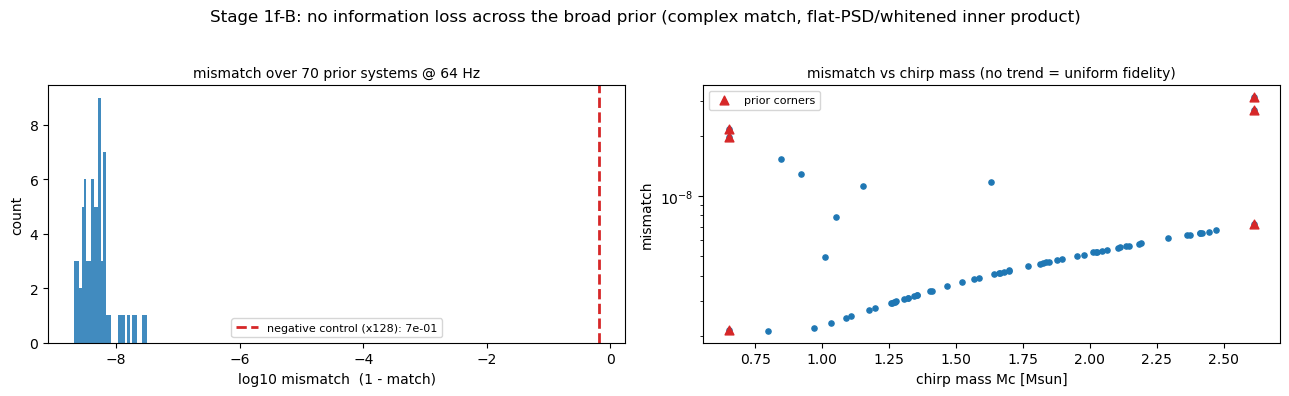

In [11]:
# ----------------------------------------------------------------------
# Stage 1f (B): PROOF of no information loss over the prior.
# N fresh broad-prior draws + the 6 corners, full chain at the adopted rate;
# mismatch distribution + negative control.
# ----------------------------------------------------------------------
N_PROOF = 64
sampler_f = read_from_config(str(REPO / 'runs/bns/gwconfig_ewbroad.yaml'), seed=23)
bf = sampler_f(N_PROOF)
th_proof = bf[:, [sampler_f.param_index[c] for c in _cols]].to(torch.float64)
th_proof[:, 5] = 0.0
th_proof = torch.cat([corners, th_proof])            # corners are part of the proof

t0f = time.time()
H_proof = gen_H(model295, th_proof)
print("generated %d exact prior waveforms in %.0f s" % (th_proof.shape[0], time.time() - t0f))

mismatches = []
for i in range(th_proof.shape[0]):
    M = run_chain(th_proof[i:i + 1], H_proof[i], FACTOR_EW)
    mismatches.append(1.0 - M)
mismatches = np.array(mismatches)

print("\nPROOF over %d systems (broad prior + corners), %d Hz (x%d):"
      % (len(mismatches), RATE_EW, FACTOR_EW))
print("  mismatch:  max = %.2e   median = %.2e   min = %.2e"
      % (mismatches.max(), np.median(mismatches), mismatches.min()))
print("  SNR retained (worst case): %.6f%%" % (100 * (1 - mismatches.max())))

# negative control: an extreme corner system, decimated 4x deeper
M_neg = run_chain(th_proof[2:3], H_proof[2], FACTOR_EW * 4)   # corner: 0.75+0.75 L=15k
print("  NEGATIVE control (x%d, rate %g Hz < 2B*): mismatch = %.2e  -> information IS lost"
      % (FACTOR_EW * 4, RATE_EW / 4, 1 - M_neg))

ok = mismatches.max() < 1e-6
print("\n==> %s: heterodyne + truncate + decimate to %d Hz preserves the signal"
      % ("PASS" if ok else "FAIL", RATE_EW))
print("    (worst mismatch %.1e, i.e. SNR loss < %.1e; the same chain at %g Hz fails by 8 orders)"
      % (mismatches.max(), mismatches.max(), RATE_EW / 4))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
Mc_proof = np.array([_mch(float(r[0]), float(r[1])) for r in th_proof])
ax[0].hist(np.log10(mismatches), bins=30, color='C0', alpha=0.85)
ax[0].axvline(np.log10(1 - M_neg), color='C3', lw=2, ls='--',
              label='negative control (x%d): %.0e' % (FACTOR_EW * 4, 1 - M_neg))
ax[0].set_xlabel('log10 mismatch  (1 - match)'); ax[0].set_ylabel('count')
ax[0].set_title('mismatch over %d prior systems @ %d Hz' % (len(mismatches), RATE_EW), fontsize=10)
ax[0].legend(fontsize=8)
sc = ax[1].scatter(Mc_proof, mismatches, s=14, c='C0')
ax[1].scatter(Mc_proof[:6], mismatches[:6], s=40, c='C3', marker='^', label='prior corners')
ax[1].set_yscale('log'); ax[1].set_xlabel('chirp mass Mc [Msun]'); ax[1].set_ylabel('mismatch')
ax[1].set_title('mismatch vs chirp mass (no trend = uniform fidelity)', fontsize=10)
ax[1].legend(fontsize=8)
fig.suptitle('Stage 1f-B: no information loss across the broad prior '
             '(complex match, flat-PSD/whitened inner product)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()